In [1]:
"""
Cell 0 - Mount Google Drive.

"""

from google.colab import drive
import os

drive.mount('/content/drive')
PROJECT_DIR = "/content/drive/MyDrive/wvc_capstone"
os.makedirs(PROJECT_DIR, exist_ok=True)

# Subfolders
for sub in ["dem_tiles", "slope_tiles", "data_oregon"]:
    os.makedirs(os.path.join(PROJECT_DIR, sub), exist_ok=True)

print(f"Google Drive mounted. Project folder ready at: {PROJECT_DIR}")
print("\nIMPORTANT: update the paths in your other scripts to point here")
print("instead of plain /content/ or relative paths, e.g.:")
print(f'  SEGMENTS_PATH = "{PROJECT_DIR}/oregon_road_segments.geojson"')
print(f'  DEM_TILES_FOLDER = "{PROJECT_DIR}/dem_tiles"')
print("\nAlso cd into it so relative paths work without editing every script:")
print(f'  %cd {PROJECT_DIR}')

Mounted at /content/drive
Google Drive mounted. Project folder ready at: /content/drive/MyDrive/wvc_capstone

IMPORTANT: update the paths in your other scripts to point here
instead of plain /content/ or relative paths, e.g.:
  SEGMENTS_PATH = "/content/drive/MyDrive/wvc_capstone/oregon_road_segments.geojson"
  DEM_TILES_FOLDER = "/content/drive/MyDrive/wvc_capstone/dem_tiles"

Also cd into it so relative paths work without editing every script:
  %cd /content/drive/MyDrive/wvc_capstone


In [2]:
"""
Cell 1

"""
%cd /content/drive/MyDrive/wvc_capstone

/content/drive/MyDrive/wvc_capstone


In [3]:
"""
Cell 2 - Download Oregon wildlife-vehicle-collision capstone datasets from
their ArcGIS REST services, with automatic pagination.

Requirements:
    pip install requests

Usage:
    python download_oregon_datasets.py

Each dataset is saved as a GeoJSON file in a local "data_oregon/" folder.
Already-downloaded files (non-empty, valid JSON) are skipped.
"""

import os
import json
import time
import requests

OUTPUT_DIR = "/content/drive/MyDrive/wvc_capstone/data_oregon"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# (friendly name, REST layer URL, output filename)
DATASETS = [
    (
        "ODOT Animal Incidents (Roadkill Records) - current",
        "https://gis.odot.state.or.us/arcgis1006/rest/services/agol/OTSDE_NeedsAndSafety/MapServer/206",
        "odot_animal_incidents.geojson",
    ),
    (
        "ODOT Animal Incidents Density - current",
        "https://gis.odot.state.or.us/arcgis1006/rest/services/agol/OTSDE_NeedsAndSafety/MapServer/207",
        "odot_animal_incidents_density.geojson",
    ),
    (
        "ODOT Mule Deer Migration (ODFW)",
        "https://gis.odot.state.or.us/arcgis1006/rest/services/agol/AnimalIncidentsLayers/MapServer/0",
        "odfw_mule_deer_migration.geojson",
    ),
    (
        "OCAMP Priority Wildlife Connectivity Areas",
        "https://services1.arcgis.com/CD5mKowwN6nIaqd8/arcgis/rest/services/project_sfam_or_odfw_pwcas_2023/FeatureServer/0",
        "ocamp_pwca.geojson",
    ),
    (
        "Oregon Statewide Habitat Map 2018",
        "https://arcgis-prod.oregonexplorer.info/arcgis/rest/services/_HabitatVegetation/oreall_hab_veg/MapServer/17",
        "oregon_statewide_habitat_map_2018.geojson",
    ),
]


def already_downloaded(full_path):
    """True if a valid, non-empty GeoJSON already exists at this path -
    lets us skip re-downloading datasets that survived earlier."""
    if not os.path.exists(full_path):
        return False
    try:
        with open(full_path) as f:
            data = json.load(f)
        return len(data.get("features", [])) > 0
    except Exception:
        return False  # corrupted/empty file - treat as not downloaded


def get_max_record_count(layer_url):
    resp = requests.get(layer_url, params={"f": "json"}, timeout=30)
    resp.raise_for_status()
    info = resp.json()
    return info.get("maxRecordCount", 1000)


def esri_json_to_geojson_features(esri_features):
    """Convert Esri JSON features (f=json) to GeoJSON-style features.
    Needed for layers with HasM:true geometries, which older ArcGIS
    Server versions (10.x) often fail to export directly as f=geojson
    (a known 400 'Failed to execute query' cause)."""
    out = []
    for feat in esri_features:
        geom = feat.get("geometry", {})
        attrs = feat.get("attributes", {})
        if "x" in geom and "y" in geom:
            gj_geom = {"type": "Point", "coordinates": [geom["x"], geom["y"]]}
        else:
            gj_geom = None
        out.append({"type": "Feature", "geometry": gj_geom, "properties": attrs})
    return out


def get_object_ids(layer_url, retries=3, timeout=180):
    """Fetch object IDs with retries and a longer timeout - some layers
    (e.g. the Oregon habitat/vegetation server) are genuinely slow to
    respond to returnIdsOnly, not just flaky."""
    params = {"where": "1=1", "returnIdsOnly": "true", "f": "json"}
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            resp = requests.get(f"{layer_url}/query", params=params, timeout=timeout)
            resp.raise_for_status()
            data = resp.json()
            return data.get("objectIds") or []
        except Exception as e:
            last_error = e
            print(f"    attempt {attempt}/{retries} failed ({e}), retrying..." if attempt < retries else "")
            time.sleep(5)
    raise last_error


def fetch_batch(layer_url, object_ids, oid_field="OBJECTID", timeout=180, retries=3):
    """Fetch one batch, with a longer timeout and retries - polygon-heavy
    layers (complex vegetation shapes, many vertices) can be genuinely
    slow to transfer even for a modest number of records."""
    ids_str = ",".join(str(i) for i in object_ids)
    for fmt in ("geojson", "json"):
        params = {
            "objectIds": ids_str,
            "outFields": "*",
            "f": fmt,
        }
        for attempt in range(1, retries + 1):
            try:
                resp = requests.post(f"{layer_url}/query", data=params, timeout=timeout)
                resp.raise_for_status()
                data = resp.json()
                if "error" in data:
                    break  # try the other format instead of retrying same error
                if fmt == "geojson":
                    return data.get("features", [])
                else:
                    return esri_json_to_geojson_features(data.get("features", []))
            except Exception as e:
                if attempt < retries:
                    print(f"      batch fetch attempt {attempt}/{retries} failed ({e}), retrying...")
                    time.sleep(5)
                else:
                    print(f"      batch fetch failed after {retries} attempts ({e})")
    return []


def download_layer(name, layer_url, out_path):
    full_path = os.path.join(OUTPUT_DIR, out_path)

    if already_downloaded(full_path):
        print(f"\n--- {name} ---")
        print(f"  Already downloaded, skipping -> {full_path}")
        return

    print(f"\n--- {name} ---")
    try:
        page_size = get_max_record_count(layer_url)
    except Exception as e:
        print(f"  Could not read service info: {e}")
        return
    print(f"Page size: {page_size}")

    print("  Fetching object ID list (for reliable pagination)...")
    try:
        object_ids = get_object_ids(layer_url)
    except Exception as e:
        print(f"  Could not get object IDs ({e}) - skipping this layer")
        return

    if not object_ids:
        print("  No object IDs returned - layer may be empty or restricted")
        all_features = []
    else:
        print(f"  {len(object_ids)} total records to fetch")
        batch_size = min(page_size, 200)  # smaller cap - polygon-heavy layers
                                            # (complex vegetation shapes) can
                                            # time out even at 1000 records/batch
        all_features = []
        for i in range(0, len(object_ids), batch_size):
            batch_ids = object_ids[i:i + batch_size]
            features = fetch_batch(layer_url, batch_ids)
            all_features.extend(features)
            print(f"  fetched {len(all_features)} / {len(object_ids)} records so far...")
            time.sleep(0.3)

    with open(full_path, "w") as f:
        json.dump({"type": "FeatureCollection", "features": all_features}, f)

    print(f"Saved {len(all_features)} total records -> {full_path}")
    if len(all_features) == 0:
        print("  NOTE: 0 records - this endpoint may be retired or restricted.")


if __name__ == "__main__":
    for name, url, filename in DATASETS:
        try:
            download_layer(name, url, filename)
        except Exception as e:
            print(f"FAILED: {name} -> {e}")


--- ODOT Animal Incidents (Roadkill Records) - current ---
  Already downloaded, skipping -> /content/drive/MyDrive/wvc_capstone/data_oregon/odot_animal_incidents.geojson

--- ODOT Animal Incidents Density - current ---
  Already downloaded, skipping -> /content/drive/MyDrive/wvc_capstone/data_oregon/odot_animal_incidents_density.geojson

--- ODOT Mule Deer Migration (ODFW) ---
  Already downloaded, skipping -> /content/drive/MyDrive/wvc_capstone/data_oregon/odfw_mule_deer_migration.geojson

--- OCAMP Priority Wildlife Connectivity Areas ---
  Already downloaded, skipping -> /content/drive/MyDrive/wvc_capstone/data_oregon/ocamp_pwca.geojson

--- Oregon Statewide Habitat Map 2018 ---
  Already downloaded, skipping -> /content/drive/MyDrive/wvc_capstone/data_oregon/oregon_statewide_habitat_map_2018.geojson


In [4]:
"""
Cell 4 - Extract/Inspect Road Network

"""
!pip install fiona -q
import zipfile
import os
import fiona
import geopandas as gpd

def extract_and_inspect_gdb(zip_path, extract_dir="/content/extracted_gdb"):
    gdb_name = "or_trans_network_public2021.gdb"
    extracted_gdb_path = os.path.join(extract_dir, gdb_name)

    # Extract only the GDB contents if not already extracted
    if not os.path.exists(extracted_gdb_path):
        print(f"Extracting {gdb_name} from {zip_path}...")
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            for file_info in z.infolist():
                if gdb_name in file_info.filename:
                    z.extract(file_info, extract_dir)
        print("Extraction complete!")

    try:
        print(f"Scanning layers inside extracted GDB at: {extracted_gdb_path}")
        layers = fiona.listlayers(extracted_gdb_path)
        print(f"Available layers: {layers}\n")

        if layers:
            target_layer = layers[0]
            print(f"Reading schema and metadata for layer: '{target_layer}'...")
            # Load only the first 5 rows to inspect metadata quickly
            gdf = gpd.read_file(extracted_gdb_path, layer=target_layer, rows=5)
            print("Columns in dataset:")
            print(gdf.columns.tolist())
            print("\nPreview:")
            print(gdf)
    except Exception as e:
        print(f"An error occurred while reading the GDB: {e}")

   !wget --tries=5 --timeout=30 --continue https://ftp.gis.oregon.gov/framework/transportation/OR_Trans_Network_Public_2021.zip

extract_and_inspect_gdb('OR_Trans_Network_Public_2021.zip', extract_dir="/content/drive/MyDrive/wvc_capstone/extracted_gdb")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 174.1 MB/s eta 0:00:00
--2026-10-09 18:48:07--  https://ftp.gis.oregon.gov/framework/transportation/OR_Trans_Network_Public_2021.zip
Resolving ftp.gis.oregon.gov (ftp.gis.oregon.gov)... 159.121.110.36
Connecting to ftp.gis.oregon.gov (ftp.gis.oregon.gov)|159.121.110.36|:443... failed: Connection timed out.
Retrying.

--2026-10-09 18:50:24--  (try: 2)  https://ftp.gis.oregon.gov/framework/transportation/OR_Trans_Network_Public_2021.zip
Connecting to ftp.gis.oregon.gov (ftp.gis.oregon.gov)|159.121.110.36|:443... failed: Connection timed out.
Retrying.

--2026-10-09 18:52:40--  (try: 3)  https://ftp.gis.oregon.gov/framework/transportation/OR_Trans_Network_Public_2021.zip
Connecting to ftp.gis.oregon.gov (ftp.gis.oregon.gov)|159.121.110.36|:443... failed: Connection timed out.
Retrying.

--2026-10-09 18:54:56--  (try: 4)  https://ftp.gis.oregon.gov/framew

In [5]:
"""
Cell 5 - Cut Oregon's OR-Trans road network into fixed-length segments - the
spatial backbone every other dataset (AADT, roadkill, habitat, terrain)
gets joined to.

Requirements:
    pip install geopandas shapely numpy

Usage:
    Step 1 - inspect the file's columns first (field names vary by
    dataset vintage, so check before filtering):

        python -c "from segment_road_network import inspect_columns; inspect_columns('/content/extracted_gdb/or_trans_network_public2021.gdb', layer='OR_Trans')"

    Step 2 - edit FILTER_FIELD / FILTER_VALUES below if you want to
    keep only state highways (recommended - OR-Trans includes every
    county and city road too, which is a LOT of segments if kept all).

    Step 3 - run:

        python segment_road_network.py
"""

import geopandas as gpd
from shapely.ops import substring
import numpy as np

# ============================== CONFIG ==============================

# This is a File Geodatabase (.gdb), not a plain shapefile - needs a
# layer name passed to gpd.read_file(), not just a path.
INPUT_PATH = "/content/drive/MyDrive/wvc_capstone/extracted_gdb/or_trans_network_public2021.gdb"
GDB_LAYER = "OR_Trans"
OUTPUT_PATH = "oregon_road_segments.geojson"

PROJECTED_CRS = "EPSG:5070"      # NAD83 Conus Albers - consistent with other scripts
SEGMENT_LENGTH_M = 804.672       # 0.5 mile, matching ITD's own benchmark segmentation
GRID_CELL_SIZE_M = 800           # matches capture_recapture_underreporting.py's grid

# Set these after running inspect_columns() to filter to state highways
# only. Leave both as None to keep every road (state + county + city) -
# fine for completeness but a much bigger file.
FILTER_FIELD = "ROADOWNER"
FILTER_VALUES = ["Oregon Department of Transportation"]

# ============================ FUNCTIONS ============================


def inspect_columns(path, layer=None):
    """Run this first to see what fields OR-Trans actually has, so you
    can set FILTER_FIELD/FILTER_VALUES correctly (e.g. to keep only
    state-system roads)."""
    gdf = gpd.read_file(path, layer=layer, rows=5) if layer else gpd.read_file(path, rows=5)
    print("Columns:", gdf.columns.tolist())
    print(gdf.head())
    return gdf


def load_roads(path, layer=None, filter_field=None, filter_values=None):
    print("Loading OR-Trans network...")
    gdf = gpd.read_file(path, layer=layer) if layer else gpd.read_file(path)
    print(f"  {len(gdf)} road features loaded")

    if filter_field and filter_values:
        gdf = gdf[gdf[filter_field].isin(filter_values)]
        print(f"  {len(gdf)} features after filtering on {filter_field}")

    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty]
    gdf = gdf.to_crs(PROJECTED_CRS)
    return gdf


def split_line_into_segments(line, segment_length):
    """Split a LineString (or MultiLineString) into fixed-length pieces."""
    if line.geom_type == "MultiLineString":
        parts = []
        for part in line.geoms:
            parts.extend(split_line_into_segments(part, segment_length))
        return parts

    length = line.length
    if length <= segment_length:
        return [line]

    n_segments = int(np.ceil(length / segment_length))
    segments = []
    for i in range(n_segments):
        start = i * segment_length
        end = min((i + 1) * segment_length, length)
        if end - start < 1:  # skip near-zero slivers at the end of a road
            continue
        segments.append(substring(line, start, end))
    return segments


def segment_roads(gdf, segment_length):
    print(f"Splitting roads into ~{segment_length:.0f}m segments...")
    records = []
    seg_id = 0
    total = len(gdf)

    for i, (idx, row) in enumerate(gdf.iterrows()):
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        pieces = split_line_into_segments(geom, segment_length)
        for piece in pieces:
            if piece.length < 1:
                continue
            rec = row.drop("geometry").to_dict()
            rec["segment_id"] = f"seg_{seg_id}"
            rec["segment_length_m"] = piece.length
            rec["geometry"] = piece
            records.append(rec)
            seg_id += 1
        if i % 5000 == 0 and i > 0:
            print(f"  processed {i} / {total} source roads, {seg_id} segments so far...")

    seg_gdf = gpd.GeoDataFrame(records, geometry="geometry", crs=gdf.crs)
    print(f"Created {len(seg_gdf)} total segments")
    return seg_gdf


def add_grid_id(gdf, cell_size_m):
    """Tag each segment with the same grid_id scheme used in
    capture_recapture_underreporting.py and join_aadt_to_grid.py, using
    the segment's midpoint. Lets you join at the fine segment_id level
    or the coarser grid_id level depending on what you need."""
    gdf = gdf.copy()
    midpoints = gdf.geometry.interpolate(0.5, normalized=True)
    gx = (midpoints.x // cell_size_m).astype(int)
    gy = (midpoints.y // cell_size_m).astype(int)
    gdf["grid_id"] = gx.astype(str) + "_" + gy.astype(str)
    return gdf


def main():
    gdf = load_roads(INPUT_PATH, GDB_LAYER, FILTER_FIELD, FILTER_VALUES)
    seg_gdf = segment_roads(gdf, SEGMENT_LENGTH_M)
    seg_gdf = add_grid_id(seg_gdf, GRID_CELL_SIZE_M)

    # keep a plain sequential centroid lat/lon too, for easy joins to
    # tabular (non-spatial) tools downstream
    centroids = seg_gdf.geometry.centroid
    centroids_ll = gpd.GeoSeries(centroids, crs=seg_gdf.crs).to_crs("EPSG:4326")
    seg_gdf["centroid_lat"] = centroids_ll.y
    seg_gdf["centroid_lon"] = centroids_ll.x

    seg_gdf_latlon = seg_gdf.to_crs("EPSG:4326")
    seg_gdf_latlon.to_file(OUTPUT_PATH, driver="GeoJSON")

    print(f"\nSaved {len(seg_gdf_latlon)} segments -> {OUTPUT_PATH}")
    print(
        "\nEach segment has: segment_id (unique), segment_length_m, grid_id "
        "(matches your AADT/roadkill grid files), and centroid_lat/centroid_lon.\n"
        "Next: spatial-join AADT, roadkill points, habitat polygons etc. onto "
        "segment_id for fine-grained joins, or merge on grid_id for the coarser "
        "join you've already been using."
    )


if __name__ == "__main__":
    main()

Loading OR-Trans network...
  748729 road features loaded
  21283 features after filtering on ROADOWNER
Splitting roads into ~805m segments...
  processed 5000 / 21283 source roads, 7578 segments so far...
  processed 10000 / 21283 source roads, 15126 segments so far...
  processed 15000 / 21283 source roads, 22225 segments so far...
  processed 20000 / 21283 source roads, 30379 segments so far...
Created 32173 total segments

Saved 32173 segments -> oregon_road_segments.geojson

Each segment has: segment_id (unique), segment_length_m, grid_id (matches your AADT/roadkill grid files), and centroid_lat/centroid_lon.
Next: spatial-join AADT, roadkill points, habitat polygons etc. onto segment_id for fine-grained joins, or merge on grid_id for the coarser join you've already been using.


In [6]:
"""
Cell 6 - Join the Oregon TCDS AADT export (tcds_list.xlsx) to the shared segment
grid, using the SAME 800m grid scheme as capture_recapture_underreporting.py
so this file can be merged with your wildlife-collision grid output on
grid_id.

Requirements:
    pip install pandas geopandas openpyxl

Usage:
    python join_aadt_to_grid.py
"""

import pandas as pd
import geopandas as gpd

# ============================== CONFIG ==============================

INPUT_XLSX = "/content/drive/MyDrive/wvc_capstone/tcds_list.xlsx"
OUTPUT_CSV = "/content/drive/MyDrive/wvc_capstone/aadt_by_grid.csv"

PROJECTED_CRS = "EPSG:5070"   # same CRS used in capture_recapture_underreporting.py
GRID_CELL_SIZE_M = 800        # same ~0.5 mi grid used there - MUST MATCH

# ============================ FUNCTIONS ============================


def load_tcds_export(path):
    """TCDS export has a search-criteria row above the real header row."""
    df = pd.read_excel(path, header=1)  # row 2 (0-indexed: 1) is the real header
    df = df.dropna(subset=["Latitude", "Longitude"])
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
        crs="EPSG:4326",
    )
    return gdf.to_crs(PROJECTED_CRS)


def assign_grid_cell(gdf, cell_size_m):
    """Identical binning logic to capture_recapture_underreporting.py's
    assign_grid_cell(), so grid_id values line up between the two files."""
    gdf = gdf.copy()
    gdf["_x"] = gdf.geometry.x
    gdf["_y"] = gdf.geometry.y
    gdf["_gx"] = (gdf["_x"] // cell_size_m).astype(int)
    gdf["_gy"] = (gdf["_y"] // cell_size_m).astype(int)
    gdf["grid_id"] = gdf["_gx"].astype(str) + "_" + gdf["_gy"].astype(str)
    return gdf


def main():
    print("Loading TCDS AADT export...")
    gdf = load_tcds_export(INPUT_XLSX)
    print(f"  {len(gdf)} stations with valid coordinates")

    # Drop stations with non-positive AADT: these are data errors or
    # placeholder records (e.g. "NOT A STATE HIGHWAY, use this LRS"),
    # not real traffic counts - including them drags grid-cell averages
    # negative, which is physically impossible for a traffic volume.
    bad = gdf["Latest"] <= 0
    if bad.any():
        print(f"  Dropping {bad.sum()} stations with AADT <= 0 (data errors / placeholders)")
        gdf = gdf[~bad]

    print(f"Binning into {GRID_CELL_SIZE_M}m grid cells (matching wildlife-collision grid)...")
    gdf = assign_grid_cell(gdf, GRID_CELL_SIZE_M)

    # Aggregate to one row per grid cell. Multiple stations can fall in
    # the same cell (e.g. a highway with several count stations close
    # together) - mean AADT is the summary value, with station_count so
    # you can see how many stations backed that average.
    agg = (
        gdf.groupby("grid_id")
        .agg(
            mean_aadt=("Latest", "mean"),
            max_aadt=("Latest", "max"),
            station_count=("Latest", "count"),
            centroid_x=("_x", "mean"),
            centroid_y=("_y", "mean"),
            example_route=("On", "first"),
            functional_class=("Functional Class", "first"),
            rural_urban=("Rural Urban", "first"),
        )
        .reset_index()
    )

    # convert centroids back to lat/lon for readability / further joins
    centroid_gdf = gpd.GeoDataFrame(
        agg,
        geometry=gpd.points_from_xy(agg["centroid_x"], agg["centroid_y"]),
        crs=PROJECTED_CRS,
    ).to_crs("EPSG:4326")
    agg["centroid_lat"] = centroid_gdf.geometry.y
    agg["centroid_lon"] = centroid_gdf.geometry.x
    agg = agg.drop(columns=["centroid_x", "centroid_y"])

    agg.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved {len(agg)} grid cells with AADT data -> {OUTPUT_CSV}")
    print(f"\nAADT summary across grid cells:")
    print(agg["mean_aadt"].describe())
    print(
        "\nThis file shares grid_id with underreporting_by_segment.csv "
        "(from capture_recapture_underreporting.py) - merge on grid_id "
        "to add traffic volume as a predictor alongside your wildlife "
        "collision / reporting-rate target."
    )


if __name__ == "__main__":
    main()

Loading TCDS AADT export...
  16340 stations with valid coordinates
  Dropping 17 stations with AADT <= 0 (data errors / placeholders)
Binning into 800m grid cells (matching wildlife-collision grid)...

Saved 7258 grid cells with AADT data -> /content/drive/MyDrive/wvc_capstone/aadt_by_grid.csv

AADT summary across grid cells:
count      7258.000000
mean       5782.642292
std        9795.769794
min           1.000000
25%         599.000000
50%        2525.000000
75%        7499.050000
max      175966.000000
Name: mean_aadt, dtype: float64

This file shares grid_id with underreporting_by_segment.csv (from capture_recapture_underreporting.py) - merge on grid_id to add traffic volume as a predictor alongside your wildlife collision / reporting-rate target.


In [7]:
"""
Cell 7 - Download 3DEP DEM tiles from a TNM bulk-download URL list.

Usage:
    1. Save the URL list (from TNM's "uGet Instructions" page) as
       dem_urls.txt, one URL per line.
    2. python download_dem_tiles.py
"""

import os
import requests

URL_LIST_FILE = "dem_urls.txt"
OUTPUT_FOLDER = "dem_tiles"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

with open(URL_LIST_FILE) as f:
    urls = [line.strip() for line in f if line.strip().startswith("http")]

print(f"{len(urls)} tiles to download")

for i, url in enumerate(urls, 1):
    filename = url.split("/")[-1]
    out_path = os.path.join(OUTPUT_FOLDER, filename)

    if os.path.exists(out_path):
        print(f"[{i}/{len(urls)}] {filename} already downloaded, skipping")
        continue

    print(f"[{i}/{len(urls)}] Downloading {filename}...")
    try:
        resp = requests.get(url, timeout=120, stream=True)
        resp.raise_for_status()
        with open(out_path, "wb") as out_f:
            for chunk in resp.iter_content(chunk_size=8192):
                out_f.write(chunk)
    except Exception as e:
        print(f"  FAILED: {e}")

print(f"\nDone. Tiles saved in {OUTPUT_FOLDER}/")

54 tiles to download
[1/54] USGS_1_n42w117_20240701.tif already downloaded, skipping
[2/54] USGS_1_n42w118_20260202.tif already downloaded, skipping
[3/54] USGS_1_n42w119_20260202.tif already downloaded, skipping
[4/54] USGS_1_n42w120_20260601.tif already downloaded, skipping
[5/54] USGS_1_n42w121_20260601.tif already downloaded, skipping
[6/54] USGS_1_n42w122_20260601.tif already downloaded, skipping
[7/54] USGS_1_n42w123_20260601.tif already downloaded, skipping
[8/54] USGS_1_n42w124_20260601.tif already downloaded, skipping
[9/54] USGS_1_n42w125_20260601.tif already downloaded, skipping
[10/54] USGS_1_n43w117_20240701.tif already downloaded, skipping
[11/54] USGS_1_n43w118_20260202.tif already downloaded, skipping
[12/54] USGS_1_n43w119_20260202.tif already downloaded, skipping
[13/54] USGS_1_n43w120_20260202.tif already downloaded, skipping
[14/54] USGS_1_n43w121_20260601.tif already downloaded, skipping
[15/54] USGS_1_n43w122_20260601.tif already downloaded, skipping
[16/54] USGS_

In [8]:
"""
Cell 8 - Join USGS 3DEP elevation/slope to your road segments via zonal statistics.

Unlike your other sources (points, polygons), this is RASTER data, so the
join method is different: for each segment, compute the mean elevation
and mean slope of the terrain directly under/around that segment.

Requirements:
    pip install rasterio rasterstats geopandas numpy

Usage:
    1. Download 3DEP GeoTIFF tiles covering Oregon from
       https://apps.nationalmap.gov/downloader/ (1 arc-second / ~30m)
    2. Put all downloaded .tif files in one folder
    3. Edit CONFIG below
    4. python join_terrain_to_segments.py
"""

import glob
import os

import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats
import geopandas as gpd

# ============================== CONFIG ==============================

DEM_TILES_FOLDER = "dem_tiles"              # folder of downloaded 3DEP .tif files
SLOPE_TILES_FOLDER = "slope_tiles"           # per-tile slope rasters, created by this script
MOSAIC_OUTPUT = "oregon_dem_mosaic.tif"      # merged DEM, created by this script
SLOPE_OUTPUT = "oregon_slope.tif"            # merged slope, created by this script

SEGMENTS_PATH = "oregon_road_segments.geojson"
OUTPUT_CSV = "terrain_by_segment.csv"

# Segments are lines, not polygons - buffer them slightly so zonal stats
# has an actual area to sample rather than a zero-width line. ~30m
# buffer roughly matches the DEM's own pixel size.
SEGMENT_BUFFER_M = 30
PROJECTED_CRS = "EPSG:5070"  # consistent with your other scripts

# ============================ FUNCTIONS ============================


def mosaic_dem_tiles(tiles_folder, output_path):
    """Merge all downloaded DEM tiles into one GeoTIFF."""
    tile_paths = glob.glob(os.path.join(tiles_folder, "*.tif"))
    if not tile_paths:
        raise FileNotFoundError(
            f"No .tif files found in {tiles_folder} - download 3DEP tiles first."
        )
    print(f"Found {len(tile_paths)} DEM tiles, mosaicking...")

    sources = [rasterio.open(p) for p in tile_paths]
    mosaic, out_transform = merge(sources)

    out_meta = sources[0].meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_transform,
    })

    with rasterio.open(output_path, "w", **out_meta) as dest:
        dest.write(mosaic)

    for s in sources:
        s.close()

    print(f"Saved mosaic -> {output_path}")
    return output_path


def compute_slope_for_tile(dem_tile_path, slope_tile_path, target_crs):
    """Compute slope (degrees) for ONE small tile at a time - keeps peak
    memory to a single ~3601x3601 tile instead of the full statewide
    mosaic (~470M pixels), which is what was crashing the Colab runtime.

    If the source tile is in a geographic CRS (lat/lon degrees - the
    normal case for 3DEP downloads), it's reprojected to target_crs
    (meters) FIRST. Computing a gradient directly on geographic data
    divides real elevation differences (meters) by tiny degree-sized
    pixel steps, which blows up the slope to ~90 degrees everywhere -
    silently wrong, not an error, which is why this matters."""
    with rasterio.open(dem_tile_path) as src:
        if src.crs and src.crs.is_geographic:
            transform, width, height = calculate_default_transform(
                src.crs, target_crs, src.width, src.height, *src.bounds
            )
            out_meta = src.meta.copy()
            out_meta.update({
                "crs": target_crs,
                "transform": transform,
                "width": width,
                "height": height,
                "dtype": "float32",
            })
            elevation = np.empty((height, width), dtype=np.float32)
            reproject(
                source=rasterio.band(src, 1),
                destination=elevation,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.bilinear,
            )
            pixel_size_x = transform[0]
            pixel_size_y = -transform[4]
        else:
            elevation = src.read(1).astype(np.float32)
            transform = src.transform
            out_meta = src.meta.copy()
            pixel_size_x = transform[0]
            pixel_size_y = -transform[4]

    dzdx = np.gradient(elevation, axis=1) / pixel_size_x
    dzdy = np.gradient(elevation, axis=0) / pixel_size_y
    slope_rad = np.arctan(np.sqrt(dzdx**2 + dzdy**2))
    slope_deg = np.degrees(slope_rad).astype(np.float32)

    out_meta.update(dtype="float32")
    with rasterio.open(slope_tile_path, "w", **out_meta) as dest:
        dest.write(slope_deg, 1)


def compute_slope_per_tile(tiles_folder, slope_tiles_folder):
    """Run compute_slope_for_tile() on every DEM tile individually, then
    return the folder of per-tile slope rasters ready to be mosaicked."""
    os.makedirs(slope_tiles_folder, exist_ok=True)
    tile_paths = sorted(glob.glob(os.path.join(tiles_folder, "*.tif")))
    print(f"Computing slope for {len(tile_paths)} tiles individually (low memory)...")

    for i, tile_path in enumerate(tile_paths, 1):
        filename = os.path.basename(tile_path)
        out_path = os.path.join(slope_tiles_folder, filename)
        if os.path.exists(out_path):
            print(f"  [{i}/{len(tile_paths)}] {filename} already done, skipping")
            continue
        compute_slope_for_tile(tile_path, out_path, PROJECTED_CRS)
        print(f"  [{i}/{len(tile_paths)}] {filename} done")

    return slope_tiles_folder


def join_to_segments(segments_path, dem_path, slope_path, buffer_m, output_csv):
    print("Loading segments...")
    segs = gpd.read_file(segments_path)
    print(f"  {len(segs)} segments")

    # Buffer in a PROJECTED (meters) CRS, so "30m" actually means 30
    # meters - then reproject the (small) buffered segments to match
    # whatever CRS the (large) raster is actually in, rather than
    # reprojecting the raster itself. zonal_stats assumes the vector
    # and raster share a CRS; mismatched CRSes produce nonsensical
    # window requests ("Wrong values in DstRect").
    segs_proj = segs.to_crs(PROJECTED_CRS)
    segs_proj["geometry"] = segs_proj.geometry.buffer(buffer_m)

    # Elevation mosaic and slope mosaic can be in DIFFERENT CRSes now
    # (slope tiles get reprojected to a projected CRS before the gradient
    # step; the elevation mosaic is untouched) - reproject segments
    # separately for each raster rather than assuming they match.
    with rasterio.open(dem_path) as src:
        dem_crs = src.crs
    with rasterio.open(slope_path) as src:
        slope_crs = src.crs
    print(f"  Elevation raster CRS: {dem_crs}")
    print(f"  Slope raster CRS: {slope_crs}")

    segs_for_elev = segs_proj.to_crs(dem_crs)
    segs_for_slope = segs_proj.to_crs(slope_crs)

    print("Running zonal statistics for elevation...")
    elev_stats = zonal_stats(
        segs_for_elev, dem_path, stats=["mean", "min", "max"], nodata=-999999
    )

    print("Running zonal statistics for slope...")
    slope_stats = zonal_stats(segs_for_slope, slope_path, stats=["mean", "max"])

    segs["elevation_mean_m"] = [s["mean"] for s in elev_stats]
    segs["elevation_min_m"] = [s["min"] for s in elev_stats]
    segs["elevation_max_m"] = [s["max"] for s in elev_stats]
    segs["slope_mean_deg"] = [s["mean"] for s in slope_stats]
    segs["slope_max_deg"] = [s["max"] for s in slope_stats]

    out_cols = ["segment_id", "grid_id", "elevation_mean_m", "elevation_min_m",
                "elevation_max_m", "slope_mean_deg", "slope_max_deg"]
    out_cols = [c for c in out_cols if c in segs.columns]
    segs[out_cols].to_csv(output_csv, index=False)

    print(f"\nSaved terrain data for {len(segs)} segments -> {output_csv}")
    print(f"\nElevation summary:\n{segs['elevation_mean_m'].describe()}")
    print(f"\nSlope summary:\n{segs['slope_mean_deg'].describe()}")


def main():
    # Slope computed PER TILE first (small, low memory), before any
    # mosaicking - this is the fix for the Colab crash.
    if not os.path.exists(SLOPE_OUTPUT):
        compute_slope_per_tile(DEM_TILES_FOLDER, SLOPE_TILES_FOLDER)
        mosaic_dem_tiles(SLOPE_TILES_FOLDER, SLOPE_OUTPUT)
    else:
        print(f"Using existing slope mosaic: {SLOPE_OUTPUT}")

    if not os.path.exists(MOSAIC_OUTPUT):
        mosaic_dem_tiles(DEM_TILES_FOLDER, MOSAIC_OUTPUT)
    else:
        print(f"Using existing DEM mosaic: {MOSAIC_OUTPUT}")

    join_to_segments(SEGMENTS_PATH, MOSAIC_OUTPUT, SLOPE_OUTPUT, SEGMENT_BUFFER_M, OUTPUT_CSV)


if __name__ == "__main__":
    main()

Using existing slope mosaic: oregon_slope.tif
Using existing DEM mosaic: oregon_dem_mosaic.tif
Loading segments...
  32173 segments
  Elevation raster CRS: EPSG:4269
  Slope raster CRS: EPSG:5070
Running zonal statistics for elevation...
Running zonal statistics for slope...

Saved terrain data for 32173 segments -> terrain_by_segment.csv

Elevation summary:
count    32173.000000
mean       480.352158
std        491.203794
min          0.373347
25%         63.377802
50%        219.932427
75%        893.810493
max       1951.409526
Name: elevation_mean_m, dtype: float64

Slope summary:
count    32173.000000
mean         3.359615
std          4.910111
min          0.000000
25%          0.000000
50%          1.480735
75%          4.380651
max         70.845074
Name: slope_mean_deg, dtype: float64


In [12]:
"""
Cell 10 - Download Oregon census tract boundaries + population (ACS 5-year), then
join population density to road segments.

Requirements:
    pip install requests geopandas pandas

Usage:
    python download_census_population.py
"""

import os
import requests
import pandas as pd
import geopandas as gpd

OUTPUT_DIR = "/content/drive/MyDrive/wvc_capstone/data_oregon"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRACT_SHAPEFILE_URL = "https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_41_tract.zip"
TRACT_ZIP_PATH = os.path.join(OUTPUT_DIR, "tl_2023_41_tract.zip")

# ACS 5-year, most recent available, Oregon (state FIPS 41), total population (B01003_001E)
ACS_API_URL = "https://api.census.gov/data/2022/acs/acs5"
ACS_PARAMS = {"get": "NAME,B01003_001E", "for": "tract:*", "in": "state:41"}

# Census API throttles/empties unkeyed requests more aggressively than it
# used to. A free key removes this: https://api.census.gov/data/key_signup.html
# NEVER hardcode the key here - pull it from a Colab secret (or an env var)
# so it never ends up committed to this notebook.

from google.colab import userdata
CENSUS_API_KEY = userdata.get("CENSUS_API_KEY")

SEGMENTS_PATH = "/content/drive/MyDrive/wvc_capstone/oregon_road_segments.geojson"
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "..", "population_by_segment.csv")
PROJECTED_CRS = "EPSG:5070"


def download_tract_shapefile():
    if os.path.exists(TRACT_ZIP_PATH):
        print("Tract shapefile already downloaded, skipping")
        return
    print("Downloading Oregon census tract boundaries...")
    resp = requests.get(TRACT_SHAPEFILE_URL, timeout=120)
    resp.raise_for_status()
    with open(TRACT_ZIP_PATH, "wb") as f:
        f.write(resp.content)
    print(f"Saved -> {TRACT_ZIP_PATH}")


def fetch_acs_population():
    print("Fetching ACS population data...")
    params = dict(ACS_PARAMS)
    if CENSUS_API_KEY:
        params["key"] = CENSUS_API_KEY

    headers = {"User-Agent": "Mozilla/5.0 (research script)"}  # some endpoints
                                                                  # block the default
                                                                  # python-requests UA
    resp = requests.get(ACS_API_URL, params=params, headers=headers, timeout=60)

    print(f"  Status code: {resp.status_code}")
    print(f"  Response length: {len(resp.text)} chars")
    print(f"  First 1000 chars of response:\n{resp.text[:1000]}")

    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    df["B01003_001E"] = pd.to_numeric(df["B01003_001E"], errors="coerce")
    # GEOID to match TIGER shapefile's GEOID field: state+county+tract
    df["GEOID"] = df["state"] + df["county"] + df["tract"]
    print(f"  {len(df)} tracts with population data")
    return df[["GEOID", "B01003_001E"]].rename(columns={"B01003_001E": "population"})


def main():
    download_tract_shapefile()
    pop_df = fetch_acs_population()

    print("Loading tract boundaries...")
    tracts = gpd.read_file(f"zip://{TRACT_ZIP_PATH}")
    print(f"  {len(tracts)} tracts loaded")

    tracts = tracts.merge(pop_df, on="GEOID", how="left")
    tracts_proj = tracts.to_crs(PROJECTED_CRS)
    # ALAND is already in square meters
    tracts_proj["area_km2"] = tracts_proj.geometry.area / 1e6
    tracts_proj["pop_density_per_km2"] = tracts_proj["population"] / tracts_proj["area_km2"]

    print("Loading segments...")
    segs = gpd.read_file(SEGMENTS_PATH)
    print(f"  {len(segs)} segments")
    segs_proj = segs.to_crs(PROJECTED_CRS)
    segs_proj["centroid"] = segs_proj.geometry.centroid
    seg_points = gpd.GeoDataFrame(
        segs_proj[["segment_id", "grid_id"]], geometry=segs_proj["centroid"], crs=PROJECTED_CRS
    )

    print("Joining segments to tracts...")
    joined = gpd.sjoin(
        seg_points, tracts_proj[["GEOID", "population", "area_km2", "pop_density_per_km2", "geometry"]],
        how="left", predicate="within",
    )

    out = joined[["segment_id", "grid_id", "GEOID", "population", "area_km2", "pop_density_per_km2"]]
    out.to_csv(OUTPUT_CSV, index=False)

    print(f"\nSaved {len(out)} segments with population data -> {OUTPUT_CSV}")
    print(f"\nPopulation density summary:\n{out['pop_density_per_km2'].describe()}")
    unmatched = out["GEOID"].isna().sum()
    if unmatched:
        print(f"\nNOTE: {unmatched} segments did not fall inside any tract (likely edge/water areas)")


if __name__ == "__main__":
    main()

Tract shapefile already downloaded, skipping
Fetching ACS population data...
  Status code: 200
  Response length: 75355 chars
  First 1000 chars of response:
[["NAME","B01003_001E","state","county","tract"],
["Census Tract 9501; Baker County; Oregon","2659","41","001","950100"],
["Census Tract 9502; Baker County; Oregon","3305","41","001","950200"],
["Census Tract 9503; Baker County; Oregon","2874","41","001","950300"],
["Census Tract 9504; Baker County; Oregon","2910","41","001","950400"],
["Census Tract 9505; Baker County; Oregon","2661","41","001","950500"],
["Census Tract 9506; Baker County; Oregon","2276","41","001","950600"],
["Census Tract 1.01; Benton County; Oregon","3997","41","003","000101"],
["Census Tract 1.02; Benton County; Oregon","3341","41","003","000102"],
["Census Tract 2.02; Benton County; Oregon","5802","41","003","000202"],
["Census Tract 4.01; Benton County; Oregon","3096","41","003","000401"],
["Census Tract 4.02; Benton County; Oregon","5167","41","003","0004

In [13]:
"""
Cell 11 - Join the three remaining polygon datasets - Oregon Statewide Habitat Map
2018, OCAMP connectivity, and ODFW Mule Deer Migration corridors - to
road segments.

Unlike terrain/weather (continuous rasters), these are categorical
polygon layers, so the join is: does this segment's buffer overlap one
or more polygons, and what are their attributes. Since the exact field
names in each file aren't known ahead of time, this script prints each
dataset's columns first so you can see what's actually useful before
the next modeling step.

Requirements:
    pip install geopandas pandas

Usage:
    python join_polygons_to_segments.py
"""

import os
import geopandas as gpd
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/wvc_capstone/data_oregon"
SEGMENTS_PATH = "/content/drive/MyDrive/wvc_capstone/oregon_road_segments.geojson"
OUTPUT_CSV = "/content/drive/MyDrive/wvc_capstone/polygon_features_by_segment.csv"

PROJECTED_CRS = "EPSG:5070"
SEGMENT_BUFFER_M = 200  # small buffer for polygon overlap - these are
                          # land-cover/habitat/connectivity layers, not
                          # sparse point data like PRISM, so a tight
                          # buffer around the actual road is appropriate

DATASETS = {
    "habitat": os.path.join(DATA_DIR, "oregon_statewide_habitat_map_2018.geojson"),
    "ocamp": os.path.join(DATA_DIR, "ocamp_pwca.geojson"),
    "migration": os.path.join(DATA_DIR, "odfw_mule_deer_migration.geojson"),
}


def load_and_inspect(name, path):
    print(f"\n=== {name} ===")
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty]
    print(f"  {len(gdf)} features")
    print(f"  Columns: {[c for c in gdf.columns if c != 'geometry']}")
    return gdf


def join_one_dataset(name, gdf, segs_buffered, projected_crs):
    gdf_proj = gdf.to_crs(projected_crs)

    joined = gpd.sjoin(
        segs_buffered[["segment_id", "grid_id", "geometry"]],
        gdf_proj,
        how="left",
        predicate="intersects",
    )

    # FIX: gpd.sjoin(how="left") returns one row per segment even when
    # nothing matches (right-side columns are NaN, including index_right).
    # Without filtering those out, .groupby().size() counts that phantom
    # row too, making overlap_count >= 1 and intersects = True for every
    # segment regardless of whether a real overlap occurred. Keep only
    # rows where a genuine match happened before counting/aggregating.
    matched = joined[joined["index_right"].notna()]

    # overlap count: how many polygons from this dataset touch the segment
    overlap_count = matched.groupby("segment_id").size().rename(f"{name}_overlap_count")

    # does it intersect at all
    intersects = (overlap_count > 0).rename(f"{name}_intersects")

    # first non-null value of each attribute column, per segment - a
    # representative tag, not a full list (keeps the output flat/usable)
    attr_cols = [c for c in gdf_proj.columns if c not in ("geometry",)]
    first_vals = (
        matched.groupby("segment_id")[attr_cols]
        .first()
        .add_prefix(f"{name}_")
    )

    result = pd.concat([overlap_count, intersects, first_vals], axis=1).reset_index()
    return result


def main():
    print("Loading segments...")
    segs = gpd.read_file(SEGMENTS_PATH)
    print(f"  {len(segs)} segments")
    segs_proj = segs.to_crs(PROJECTED_CRS)
    segs_buffered = segs_proj.copy()
    segs_buffered["geometry"] = segs_buffered.geometry.buffer(SEGMENT_BUFFER_M)

    out = segs[["segment_id", "grid_id"]].copy()

    for name, path in DATASETS.items():
        if not os.path.exists(path):
            print(f"\n=== {name} ===\n  FILE NOT FOUND: {path} - skipping")
            continue

        gdf = load_and_inspect(name, path)
        if len(gdf) == 0:
            print(f"  No usable features - skipping join")
            continue

        print(f"  Joining to segments (buffer {SEGMENT_BUFFER_M}m)...")
        result = join_one_dataset(name, gdf, segs_buffered, PROJECTED_CRS)
        out = out.merge(result, on="segment_id", how="left")

        intersects_col = f"{name}_intersects"
        if intersects_col in out.columns:
            out[intersects_col] = out[intersects_col].fillna(False)
            pct = 100 * out[intersects_col].mean()
            print(f"  {pct:.1f}% of segments intersect at least one {name} feature")

        # The migration dataset includes a statewide background polygon
        # with no GRIDCODE, alongside the actual ranked corridor polygons
        # (GRIDCODE 1-4). "intersects" alone is misleading here (it's
        # ~100% because of the background polygon) - add a flag for
        # genuine corridor membership instead.
        gridcode_col = f"{name}_GRIDCODE"
        if gridcode_col in out.columns:
            out[f"{name}_in_ranked_corridor"] = out[gridcode_col].notna()
            real_pct = 100 * out[f"{name}_in_ranked_corridor"].mean()
            print(f"  {real_pct:.1f}% of segments fall in an actual RANKED {name} corridor (GRIDCODE present)")

    out.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved {len(out)} segments with polygon features -> {OUTPUT_CSV}")
    print(f"\nColumns in output: {out.columns.tolist()}")


if __name__ == "__main__":
    main()

Loading segments...
  32173 segments

=== habitat ===
  6924 features
  Columns: ['objectid', 'sde.gis.bio_or_veg_actual_1992.area', 'perimeter', 'stateveg_', 'stateveg_i', 'symbol', 'veg_code', 'dom_code', 'com_code', 'veg_name', 'sci_name', 'habitat', 'st_area(shape)', 'st_perimeter(shape)']
  Joining to segments (buffer 200m)...
  100.0% of segments intersect at least one habitat feature

=== ocamp ===
  3364 features
  Columns: ['OBJECTID', 'Name', 'MoreInfo', 'Descr', 'Shape__Area', 'Shape__Length']
  Joining to segments (buffer 200m)...


/tmp/ipykernel_7073/1531163470.py:113: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[intersects_col] = out[intersects_col].fillna(False)


  40.1% of segments intersect at least one ocamp feature

=== migration ===
  3973 features
  Columns: ['ID', 'GRIDCODE', 'OBJECTID', 'Shape_Length', 'Shape_Area']
  Joining to segments (buffer 200m)...


/tmp/ipykernel_7073/1531163470.py:113: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[intersects_col] = out[intersects_col].fillna(False)


  3.8% of segments intersect at least one migration feature
  3.8% of segments fall in an actual RANKED migration corridor (GRIDCODE present)

Saved 32173 segments with polygon features -> /content/drive/MyDrive/wvc_capstone/polygon_features_by_segment.csv

Columns in output: ['segment_id', 'grid_id', 'habitat_overlap_count', 'habitat_intersects', 'habitat_objectid', 'habitat_sde.gis.bio_or_veg_actual_1992.area', 'habitat_perimeter', 'habitat_stateveg_', 'habitat_stateveg_i', 'habitat_symbol', 'habitat_veg_code', 'habitat_dom_code', 'habitat_com_code', 'habitat_veg_name', 'habitat_sci_name', 'habitat_habitat', 'habitat_st_area(shape)', 'habitat_st_perimeter(shape)', 'ocamp_overlap_count', 'ocamp_intersects', 'ocamp_OBJECTID', 'ocamp_Name', 'ocamp_MoreInfo', 'ocamp_Descr', 'ocamp_Shape__Area', 'ocamp_Shape__Length', 'migration_overlap_count', 'migration_intersects', 'migration_ID', 'migration_GRIDCODE', 'migration_OBJECTID', 'migration_Shape_Length', 'migration_Shape_Area', 'migration_i

In [14]:
"""
Cell 12 - Spatially join ODOT Animal Incidents (roadkill points) to road segments,
and aggregate to segment x month counts - your target variable.

Requirements:
    pip install geopandas pandas

Usage:
    python join_roadkill_to_segments.py
"""

import os
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

DATA_DIR = "/content/drive/MyDrive/wvc_capstone/data_oregon"
ROADKILL_PATH = os.path.join(DATA_DIR, "odot_animal_incidents.geojson")
SEGMENTS_PATH = "/content/drive/MyDrive/wvc_capstone/oregon_road_segments.geojson"
OUTPUT_CSV = "/content/drive/MyDrive/wvc_capstone/roadkill_by_segment_month.csv"

PROJECTED_CRS = "EPSG:5070"
MATCH_DISTANCE_M = 400  # ~0.25 mi - snap each roadkill point to its nearest segment


def find_date_column(gdf):
    """The exact date field name can vary - try common candidates."""
    candidates = ["DATE", "Date", "date", "INCIDENT_DATE", "EVENT_DATE", "DATETIME"]
    for c in candidates:
        if c in gdf.columns:
            return c
    # fall back: any column with "date" in its name
    for c in gdf.columns:
        if "date" in c.lower():
            return c
    return None


def main():
    print("Loading roadkill points...")
    roadkill = gpd.read_file(ROADKILL_PATH)
    print(f"  {len(roadkill)} roadkill records")
    print(f"  Columns: {[c for c in roadkill.columns if c != 'geometry']}")

    # The embedded point geometry came from the original ArcGIS service's
    # Esri JSON x/y values, which may not actually be WGS84 lon/lat (the
    # service's native SR could be Web Mercator or something else) - a
    # zero-match rate against real Oregon segments is the signature of
    # this bug. LAT/LONGTD are attribute columns straight from ODOT's
    # data and are trustworthy - rebuild geometry from those instead.
    if "LAT" in roadkill.columns and "LONGTD" in roadkill.columns:
        print("  Rebuilding geometry from LAT/LONGTD attribute columns (embedded geometry CRS was unreliable)...")
        roadkill["LAT"] = pd.to_numeric(roadkill["LAT"], errors="coerce")
        roadkill["LONGTD"] = pd.to_numeric(roadkill["LONGTD"], errors="coerce")
        roadkill = roadkill.dropna(subset=["LAT", "LONGTD"])
        roadkill = roadkill[(roadkill["LAT"] != 0) & (roadkill["LONGTD"] != 0)]
        roadkill = gpd.GeoDataFrame(
            roadkill.drop(columns="geometry"),
            geometry=[Point(xy) for xy in zip(roadkill["LONGTD"], roadkill["LAT"])],
            crs="EPSG:4326",
        )
        print(f"  {len(roadkill)} records with valid coordinates")
    else:
        roadkill = roadkill[roadkill.geometry.notnull()]
        print("  WARNING: no LAT/LONGTD columns found - using embedded geometry as-is (may be unreliable)")

    date_col = find_date_column(roadkill)
    if date_col:
        print(f"  Using '{date_col}' as the date field")
        # ArcGIS/Esri services return dates as Unix epoch MILLISECONDS
        # (a big integer), not a date string. pandas defaults to treating
        # raw numbers as nanoseconds-since-epoch, which silently produces
        # dates around 1970 instead of raising an error - try ms first,
        # fall back to normal parsing if that doesn't work (e.g. if this
        # ever runs against a differently-formatted source).
        parsed = pd.to_datetime(roadkill[date_col], unit="ms", errors="coerce")
        if parsed.notna().sum() == 0 or parsed.dt.year.max() < 1990:
            parsed = pd.to_datetime(roadkill[date_col], errors="coerce")
        roadkill[date_col] = parsed
        roadkill = roadkill.dropna(subset=[date_col])
        roadkill["year"] = roadkill[date_col].dt.year
        roadkill["month"] = roadkill[date_col].dt.month.astype(str).str.zfill(2)
    else:
        print("  WARNING: no date column found - target will be a single static count per segment, not segment x month")

    roadkill_proj = roadkill.to_crs(PROJECTED_CRS)

    print("Loading segments...")
    segs = gpd.read_file(SEGMENTS_PATH)
    print(f"  {len(segs)} segments")
    segs_proj = segs.to_crs(PROJECTED_CRS)

    print(f"Snapping roadkill points to nearest segment (within {MATCH_DISTANCE_M}m)...")
    joined = gpd.sjoin_nearest(
        roadkill_proj, segs_proj[["segment_id", "grid_id", "geometry"]],
        how="left", max_distance=MATCH_DISTANCE_M, distance_col="snap_distance_m",
    )
    matched = joined["segment_id"].notna().sum()
    print(f"  {matched} / {len(joined)} roadkill points matched to a segment within {MATCH_DISTANCE_M}m")

    joined = joined.dropna(subset=["segment_id"])

    if date_col:
        counts = (
            joined.groupby(["segment_id", "grid_id", "year", "month"])
            .size()
            .rename("roadkill_count")
            .reset_index()
        )
    else:
        counts = (
            joined.groupby(["segment_id", "grid_id"])
            .size()
            .rename("roadkill_count")
            .reset_index()
        )

    counts.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved {len(counts)} rows -> {OUTPUT_CSV}")
    print(f"\nRoadkill count summary:\n{counts['roadkill_count'].describe()}")
    if date_col:
        print(f"\nYear range: {counts['year'].min()} - {counts['year'].max()}")
        print(f"Unique segments with at least one roadkill record: {counts['segment_id'].nunique()}")


if __name__ == "__main__":
    main()

Loading roadkill points...
  104528 roadkill records
  Columns: ['OBJECTID', 'ID', 'DATE', 'ANIMAL', 'HWYNUMB', 'MP', 'YEAR', 'SEASON', 'LRM_KEY', 'LAT', 'LONGTD', 'EFFECTV_DT', 'GIS_PRC_DT']
  Rebuilding geometry from LAT/LONGTD attribute columns (embedded geometry CRS was unreliable)...
  104528 records with valid coordinates
  Using 'DATE' as the date field
Loading segments...
  32173 segments
Snapping roadkill points to nearest segment (within 400m)...
  104589 / 104591 roadkill points matched to a segment within 400m

Saved 94422 rows -> /content/drive/MyDrive/wvc_capstone/roadkill_by_segment_month.csv

Roadkill count summary:
count    94422.000000
mean         1.107676
std          0.369628
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          7.000000
Name: roadkill_count, dtype: float64

Year range: 2009 - 2025
Unique segments with at least one roadkill record: 15996


In [15]:
"""
Cell 13 - Download monthly PRISM climate grids (precipitation, mean temperature)
via the PRISM/NACSE web service - one request per month, no FTP
filename-guessing needed.

Requirements:
    pip install requests

Usage:
    python download_prism_monthly.py
"""

import os
import zipfile
import requests

# ============================== CONFIG ==============================

OUTPUT_FOLDER = "prism_data"
VARIABLES = ["ppt", "tmean"]   # precipitation, mean temperature
START_YEAR = 2015
END_YEAR = 2025                # inclusive

# PRISM migrated to this new consolidated web service on 1 Oct 2025 -
# the old services.nacse.org/prism/data/public/4km endpoint is retired.
# format=bil keeps the rest of this pipeline (and join_weather_to_segments.py,
# which looks for .bil files) unchanged; the new default is COG GeoTIFF.
BASE_URL = "https://services.nacse.org/prism/data/get/us/4km"
FORMAT_PARAM = "?format=bil"

# ============================ FUNCTIONS ============================


def download_month(variable, year, month, output_folder):
    yyyymm = f"{year}{month:02d}"
    url = f"{BASE_URL}/{variable}/{yyyymm}{FORMAT_PARAM}"

    var_folder = os.path.join(output_folder, variable, yyyymm)
    if os.path.exists(var_folder) and any(
        f.endswith(".bil") for f in os.listdir(var_folder)
    ):
        return "skipped"  # already downloaded and unzipped

    os.makedirs(var_folder, exist_ok=True)
    zip_path = os.path.join(var_folder, f"{variable}_{yyyymm}.zip")

    resp = requests.get(url, timeout=60)

    if resp.status_code == 404:
        return "no data available (404 - month not yet processed, or out of range)"
    resp.raise_for_status()

    if resp.headers.get("Content-Type", "").startswith("text"):
        # PRISM returns an error page (not a zip) for bad/unavailable requests
        return f"no data available ({resp.text[:100]})"

    with open(zip_path, "wb") as f:
        f.write(resp.content)

    with zipfile.ZipFile(zip_path) as z:
        z.extractall(var_folder)
    os.remove(zip_path)

    return "downloaded"


def main():
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    total = 0
    for variable in VARIABLES:
        for year in range(START_YEAR, END_YEAR + 1):
            for month in range(1, 13):
                total += 1
                status = download_month(variable, year, month, OUTPUT_FOLDER)
                print(f"[{variable} {year}-{month:02d}] {status}")

    print(f"\nDone. {total} month-variable combinations processed.")
    print(f"Data saved under {OUTPUT_FOLDER}/<variable>/<YYYYMM>/*.bil")


if __name__ == "__main__":
    main()

[ppt 2015-01] skipped
[ppt 2015-02] skipped
[ppt 2015-03] skipped
[ppt 2015-04] skipped
[ppt 2015-05] skipped
[ppt 2015-06] skipped
[ppt 2015-07] skipped
[ppt 2015-08] skipped
[ppt 2015-09] skipped
[ppt 2015-10] skipped
[ppt 2015-11] skipped
[ppt 2015-12] skipped
[ppt 2016-01] skipped
[ppt 2016-02] skipped
[ppt 2016-03] skipped
[ppt 2016-04] skipped
[ppt 2016-05] skipped
[ppt 2016-06] skipped
[ppt 2016-07] skipped
[ppt 2016-08] skipped
[ppt 2016-09] skipped
[ppt 2016-10] skipped
[ppt 2016-11] skipped
[ppt 2016-12] skipped
[ppt 2017-01] skipped
[ppt 2017-02] skipped
[ppt 2017-03] skipped
[ppt 2017-04] skipped
[ppt 2017-05] skipped
[ppt 2017-06] skipped
[ppt 2017-07] skipped
[ppt 2017-08] skipped
[ppt 2017-09] skipped
[ppt 2017-10] skipped
[ppt 2017-11] skipped
[ppt 2017-12] skipped
[ppt 2018-01] skipped
[ppt 2018-02] skipped
[ppt 2018-03] skipped
[ppt 2018-04] skipped
[ppt 2018-05] skipped
[ppt 2018-06] skipped
[ppt 2018-07] skipped
[ppt 2018-08] skipped
[ppt 2018-09] skipped
[ppt 2018-

In [16]:
"""
Cell 14 - Join monthly PRISM precipitation/temperature to road segments.

Unlike terrain (static, one value per segment forever), weather is
TIME-VARYING: each segment gets a different value per month. This
script builds that segment x month panel - the first real piece of
your spatiotemporal dataset structure.

Requirements:
    pip install rasterstats geopandas rasterio pandas

Usage:
    python join_weather_to_segments.py
"""

import glob
import os

import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

# ============================== CONFIG ==============================

SEGMENTS_PATH = "oregon_road_segments.geojson"
PRISM_FOLDER = "prism_data"
VARIABLES = ["ppt", "tmean"]

SEGMENT_BUFFER_M = 2000  # PRISM is 4km resolution - a small buffer like
                          # terrain's 30m would often miss the pixel
                          # entirely. 2km gets a meaningful sample without
                          # averaging across too many neighboring cells.
PROJECTED_CRS = "EPSG:5070"

OUTPUT_CSV = "weather_by_segment_month.csv"

# ============================ FUNCTIONS ============================


def find_bil_file(variable, yyyymm, prism_folder):
    folder = os.path.join(prism_folder, variable, yyyymm)
    matches = glob.glob(os.path.join(folder, "*.bil"))
    return matches[0] if matches else None


def prepare_segments(segments_path, buffer_m, projected_crs):
    print("Loading and buffering segments...")
    segs = gpd.read_file(segments_path)
    segs_proj = segs.to_crs(projected_crs)
    segs_proj["geometry"] = segs_proj.geometry.buffer(buffer_m)
    print(f"  {len(segs_proj)} segments ready")
    return segs, segs_proj


def load_existing_output(output_csv):
    """Resume support: if a previous run already wrote OUTPUT_CSV, read it
    and return (dataframe, set-of-yyyymm-already-done) so main() can skip
    redoing zonal_stats (the expensive part) for months that are already
    there. dtype=str on year/month keeps "01" as "01" instead of being
    read back as the int 1, so it matches yyyymm[4:6] exactly."""
    if not os.path.exists(output_csv):
        return None, set()
    existing = pd.read_csv(output_csv, dtype={"year": str, "month": str})
    existing["month"] = existing["month"].str.zfill(2)
    done = set(existing["year"] + existing["month"])
    print(f"Found existing {output_csv} with {len(done)} year-months already processed - will skip those")
    return existing, done


def main():
    segs, segs_proj = prepare_segments(SEGMENTS_PATH, SEGMENT_BUFFER_M, PROJECTED_CRS)

    existing_panel, done_yyyymms = load_existing_output(OUTPUT_CSV)

    # Find all available year-months from what's actually on disk (lets
    # this pick up however much download_prism_monthly.py has pulled,
    # even if it's a partial/in-progress download)
    yyyymm_set = set()
    for variable in VARIABLES:
        var_dir = os.path.join(PRISM_FOLDER, variable)
        if os.path.exists(var_dir):
            yyyymm_set.update(os.listdir(var_dir))
    yyyymms = sorted(yyyymm_set)
    print(f"Found {len(yyyymms)} year-months of data on disk")

    yyyymms_to_process = [m for m in yyyymms if m not in done_yyyymms]
    print(f"  {len(yyyymms) - len(yyyymms_to_process)} already in {OUTPUT_CSV}, "
          f"{len(yyyymms_to_process)} new to process")

    if not yyyymms_to_process:
        print("\nNothing new to process - output is already up to date.")
        return

    # Reproject segments ONCE per raster CRS (PRISM's CRS is consistent
    # across all files, so this only needs to happen once, not per month)
    first_bil = None
    for variable in VARIABLES:
        for yyyymm in yyyymms_to_process:
            first_bil = find_bil_file(variable, yyyymm, PRISM_FOLDER)
            if first_bil:
                break
        if first_bil:
            break

    if not first_bil:
        print("No new PRISM .bil files found - run download_prism_monthly.py first")
        return

    with rasterio.open(first_bil) as src:
        prism_crs = src.crs
    print(f"PRISM raster CRS: {prism_crs}")
    segs_for_stats = segs_proj.to_crs(prism_crs)

    all_records = []

    for yyyymm in yyyymms_to_process:
        year, month = yyyymm[:4], yyyymm[4:6]
        row_values = {"year": year, "month": month}
        have_any = False

        for variable in VARIABLES:
            bil_path = find_bil_file(variable, yyyymm, PRISM_FOLDER)
            if not bil_path:
                continue
            have_any = True
            stats = zonal_stats(segs_for_stats, bil_path, stats=["mean"], nodata=-9999)
            row_values[f"{variable}_mean"] = [s["mean"] for s in stats]

        if not have_any:
            continue

        month_df = pd.DataFrame({
            "segment_id": segs["segment_id"].values,
            "grid_id": segs["grid_id"].values if "grid_id" in segs.columns else None,
            "year": year,
            "month": month,
        })
        for variable in VARIABLES:
            key = f"{variable}_mean"
            if key in row_values:
                month_df[key] = row_values[key]

        all_records.append(month_df)
        print(f"  {yyyymm}: done")

    if not all_records:
        print("No new data processed.")
        return

    new_panel = pd.concat(all_records, ignore_index=True)

    # Append to whatever was already there, instead of overwriting it -
    # this is what makes reruns resumable rather than starting from zero.
    if existing_panel is not None:
        panel = pd.concat([existing_panel, new_panel], ignore_index=True)
    else:
        panel = new_panel

    panel.to_csv(OUTPUT_CSV, index=False)

    print(f"\nSaved {len(panel)} total segment-month rows ({len(new_panel)} new) -> {OUTPUT_CSV}")
    print(f"  ({len(segs)} segments x {panel[['year', 'month']].drop_duplicates().shape[0]} months)")
    for variable in VARIABLES:
        key = f"{variable}_mean"
        if key in panel.columns:
            print(f"\n{variable} summary:\n{panel[key].describe()}")


if __name__ == "__main__":
    main()

Loading and buffering segments...
  32173 segments ready
Found existing weather_by_segment_month.csv with 132 year-months already processed - will skip those
Found 132 year-months of data on disk
  132 already in weather_by_segment_month.csv, 0 new to process

Nothing new to process - output is already up to date.


In [17]:
"""
Cell 16

"""
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy.spatial import cKDTree

BASE = "/content/drive/MyDrive/wvc_capstone"
PROJECTED_CRS = "EPSG:5070"
MAX_DONOR_DISTANCE_M = 20000   # ~5 PRISM cells; flag anything farther
MAX_ELEV_DIFF_M = 300          # flag donors on a very different terrain tier

# ============================================================
# 1. Build a grid-cell reference table: centroid + elevation
# ============================================================
print("Loading segments and terrain...")
segs = gpd.read_file(f"{BASE}/oregon_road_segments.geojson").to_crs(PROJECTED_CRS)
segs["x"] = segs.geometry.centroid.x
segs["y"] = segs.geometry.centroid.y

terrain = pd.read_csv(f"{BASE}/terrain_by_segment.csv")
segs = segs.merge(terrain[["segment_id", "elevation_mean_m"]], on="segment_id", how="left")

grid_ref = (
    segs.groupby("grid_id")
    .agg(x=("x", "mean"), y=("y", "mean"), elevation_mean_m=("elevation_mean_m", "mean"))
    .reset_index()
)
print(f"  {len(grid_ref)} unique grid cells")

# ============================================================
# 2. Collapse weather to grid-cell level. Use .first(), NOT
#    .mean() - mean() silently skips NaN and blends in valid
#    sibling-segment values for the same grid cell, which
#    masks genuinely-missing grid-months and undercounts them.
# ============================================================
print("\nLoading weather...")
weather = pd.read_csv(f"{BASE}/weather_by_segment_month.csv")
grid_weather = (
    weather.groupby(["grid_id", "year", "month"])
    .agg(ppt_mean=("ppt_mean", "first"), tmean_mean=("tmean_mean", "first"))
    .reset_index()
)
print(f"  {len(grid_weather)} grid-month rows")

missing_grid_ids = (
    grid_weather.groupby("grid_id")["ppt_mean"]
    .apply(lambda s: s.isna().all())
)
missing_grid_ids = set(missing_grid_ids[missing_grid_ids].index)
valid_grid_ids = set(grid_ref["grid_id"]) - missing_grid_ids
print(f"  Missing grid cells: {len(missing_grid_ids)} | Valid: {len(valid_grid_ids)}")

# ============================================================
# 3. Nearest valid-cell donor lookup via KDTree
# ============================================================
def build_donor_map(valid_ids, target_ids, grid_ref):
    valid_ref = grid_ref[grid_ref["grid_id"].isin(valid_ids)].reset_index(drop=True)
    target_ref = grid_ref[grid_ref["grid_id"].isin(target_ids)].reset_index(drop=True)

    tree = cKDTree(valid_ref[["x", "y"]].values)
    dist, idx = tree.query(target_ref[["x", "y"]].values, k=1)

    donor_map = target_ref[["grid_id", "elevation_mean_m"]].copy()
    donor_map["donor_grid_id"] = valid_ref.loc[idx, "grid_id"].values
    donor_map["donor_elevation_m"] = valid_ref.loc[idx, "elevation_mean_m"].values
    donor_map["donor_distance_m"] = dist
    donor_map["elev_diff_m"] = (donor_map["elevation_mean_m"] - donor_map["donor_elevation_m"]).abs()
    return donor_map.rename(columns={"elevation_mean_m": "target_elevation_m"})

print("\nFinding nearest valid donor for each missing grid cell...")
donor_map = build_donor_map(valid_grid_ids, missing_grid_ids, grid_ref)

flagged = donor_map[
    (donor_map["donor_distance_m"] > MAX_DONOR_DISTANCE_M)
    | (donor_map["elev_diff_m"] > MAX_ELEV_DIFF_M)
]
print(f"  Donor distance: mean={donor_map['donor_distance_m'].mean():.0f}m, "
      f"max={donor_map['donor_distance_m'].max():.0f}m")
print(f"  Elevation diff: mean={donor_map['elev_diff_m'].mean():.0f}m, "
      f"max={donor_map['elev_diff_m'].max():.0f}m")
print(f"  Flagged (distance > {MAX_DONOR_DISTANCE_M}m or elev diff > {MAX_ELEV_DIFF_M}m): "
      f"{len(flagged)} / {len(donor_map)}")

# ============================================================
# 4. Fill missing grid-months from donor's values, same year/month
# ============================================================
print("\nFilling missing weather from donor cells...")
donor_lookup = donor_map.set_index("grid_id")["donor_grid_id"].to_dict()
distance_lookup = donor_map.set_index("grid_id")["donor_distance_m"].to_dict()
elevdiff_lookup = donor_map.set_index("grid_id")["elev_diff_m"].to_dict()

missing_rows = grid_weather[grid_weather["grid_id"].isin(missing_grid_ids)].copy()
missing_rows["donor_grid_id"] = missing_rows["grid_id"].map(donor_lookup)

valid_lookup = grid_weather[grid_weather["grid_id"].isin(valid_grid_ids)].set_index(
    ["grid_id", "year", "month"]
)[["ppt_mean", "tmean_mean"]]

filled = missing_rows.merge(
    valid_lookup, left_on=["donor_grid_id", "year", "month"], right_index=True,
    suffixes=("", "_donor"), how="left"
)
filled["ppt_mean"] = filled["ppt_mean_donor"]
filled["tmean_mean"] = filled["tmean_mean_donor"]
filled["weather_imputed"] = True
filled["donor_distance_m"] = filled["grid_id"].map(distance_lookup)
filled["donor_elev_diff_m"] = filled["grid_id"].map(elevdiff_lookup)
filled = filled.drop(columns=["ppt_mean_donor", "tmean_mean_donor"])

print(f"  Filled {filled['ppt_mean'].notna().sum()} / {len(filled)} missing grid-month rows")
still_missing = filled["ppt_mean"].isna().sum()
if still_missing:
    print(f"  WARNING: {still_missing} rows still unfillable (donor also missing that month)")

# ============================================================
# 5. Merge filled values back into the full grid-level weather
#    table, carrying the imputed flag through
# ============================================================
grid_weather["weather_imputed"] = False
grid_weather["donor_distance_m"] = np.nan
grid_weather["donor_elev_diff_m"] = np.nan

grid_weather_final = pd.concat([
    grid_weather[~grid_weather["grid_id"].isin(missing_grid_ids)],
    filled[["grid_id", "year", "month", "ppt_mean", "tmean_mean",
            "weather_imputed", "donor_distance_m", "donor_elev_diff_m"]],
], ignore_index=True)

grid_weather_final.to_csv(f"{BASE}/weather_by_grid_month_filled.csv", index=False)
print(f"\nSaved grid-level filled weather -> {BASE}/weather_by_grid_month_filled.csv")

# ============================================================
# 6. Propagate back to segment level
# ============================================================
print("\nRebuilding segment-level weather file...")
seg_grid_map = segs[["segment_id", "grid_id"]].drop_duplicates()
weather_filled_by_segment = seg_grid_map.merge(grid_weather_final, on="grid_id", how="left")
weather_filled_by_segment.to_csv(f"{BASE}/weather_by_segment_month_filled.csv", index=False)
print(f"  {len(weather_filled_by_segment)} rows -> {BASE}/weather_by_segment_month_filled.csv")
print(f"  Remaining missing ppt_mean: {weather_filled_by_segment['ppt_mean'].isna().sum()}")

# ============================================================
# 6.5. Correct weather_imputed against ground truth — whatever
#    the exact propagation mechanism, this guarantees the flag
#    matches reality rather than trusting intermediate bookkeeping.
# ============================================================
print("\nCorrecting weather_imputed flag against ground truth...")
orig_missing_mask = weather["ppt_mean"].isna()
orig_missing_keys = set(
    zip(weather.loc[orig_missing_mask, "segment_id"],
        weather.loc[orig_missing_mask, "year"],
        weather.loc[orig_missing_mask, "month"])
)

weather_filled_by_segment["weather_imputed"] = list(
    zip(weather_filled_by_segment["segment_id"],
        weather_filled_by_segment["year"],
        weather_filled_by_segment["month"])
)
weather_filled_by_segment["weather_imputed"] = weather_filled_by_segment["weather_imputed"].isin(orig_missing_keys)

assert weather_filled_by_segment["weather_imputed"].sum() == len(orig_missing_keys), \
    f"Flag mismatch: {weather_filled_by_segment['weather_imputed'].sum()} vs {len(orig_missing_keys)}"
print(f"  weather_imputed flag corrected: {weather_filled_by_segment['weather_imputed'].sum()} rows "
      f"(matches ground truth: {len(orig_missing_keys)})")

weather_filled_by_segment.to_csv(f"{BASE}/weather_by_segment_month_filled.csv", index=False)
print(f"  Re-saved with corrected flag -> {BASE}/weather_by_segment_month_filled.csv")

# ============================================================
# 7. VALIDATION
# ============================================================
print("\n" + "=" * 70)
print("VALIDATION — hold out 300 valid grid cells, reconstruct via NN, measure error")
print("=" * 70)

rng = np.random.default_rng(42)
holdout_ids = set(rng.choice(list(valid_grid_ids), size=min(300, len(valid_grid_ids)), replace=False))
remaining_valid_ids = valid_grid_ids - holdout_ids

holdout_donor_map = build_donor_map(remaining_valid_ids, holdout_ids, grid_ref)
holdout_donor_lookup = holdout_donor_map.set_index("grid_id")["donor_grid_id"].to_dict()

true_vals = grid_weather[grid_weather["grid_id"].isin(holdout_ids)].copy()
true_vals["donor_grid_id"] = true_vals["grid_id"].map(holdout_donor_lookup)

remaining_lookup = grid_weather[grid_weather["grid_id"].isin(remaining_valid_ids)].set_index(
    ["grid_id", "year", "month"]
)[["ppt_mean", "tmean_mean"]]

recon = true_vals.drop(columns=["weather_imputed", "donor_distance_m", "donor_elev_diff_m"], errors="ignore")
recon = recon.merge(
    remaining_lookup, left_on=["donor_grid_id", "year", "month"], right_index=True,
    suffixes=("_true", "_recon"), how="left"
).dropna(subset=["ppt_mean_true", "ppt_mean_recon"])

ppt_mae = (recon["ppt_mean_true"] - recon["ppt_mean_recon"]).abs().mean()
ppt_rmse = np.sqrt(((recon["ppt_mean_true"] - recon["ppt_mean_recon"]) ** 2).mean())
tmean_mae = (recon["tmean_mean_true"] - recon["tmean_mean_recon"]).abs().mean()
tmean_rmse = np.sqrt(((recon["tmean_mean_true"] - recon["tmean_mean_recon"]) ** 2).mean())

print(f"\nPrecipitation (ppt_mean): MAE={ppt_mae:.2f}mm, RMSE={ppt_rmse:.2f}mm "
      f"(overall mean={grid_weather['ppt_mean'].mean():.2f}mm)")
print(f"Temperature (tmean_mean): MAE={tmean_mae:.2f}°C, RMSE={tmean_rmse:.2f}°C "
      f"(overall mean={grid_weather['tmean_mean'].mean():.2f}°C)")

recon = recon.merge(holdout_donor_map[["grid_id", "donor_distance_m", "elev_diff_m"]], on="grid_id")
recon["ppt_abs_err"] = (recon["ppt_mean_true"] - recon["ppt_mean_recon"]).abs()
print(f"\nError vs. donor distance (correlation): {recon['ppt_abs_err'].corr(recon['donor_distance_m']):.3f}")
print(f"Error vs. elevation diff (correlation): {recon['ppt_abs_err'].corr(recon['elev_diff_m']):.3f}")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

Loading segments and terrain...
  14730 unique grid cells

Loading weather...
  1944360 grid-month rows
  Missing grid cells: 1981 | Valid: 12749

Finding nearest valid donor for each missing grid cell...
  Donor distance: mean=946m, max=7427m
  Elevation diff: mean=13m, max=174m
  Flagged (distance > 20000m or elev diff > 300m): 0 / 1981

Filling missing weather from donor cells...
  Filled 261492 / 261492 missing grid-month rows

Saved grid-level filled weather -> /content/drive/MyDrive/wvc_capstone/weather_by_grid_month_filled.csv

Rebuilding segment-level weather file...
  4246836 rows -> /content/drive/MyDrive/wvc_capstone/weather_by_segment_month_filled.csv
  Remaining missing ppt_mean: 0

Correcting weather_imputed flag against ground truth...
  weather_imputed flag corrected: 786852 rows (matches ground truth: 786852)
  Re-saved with corrected flag -> /content/drive/MyDrive/wvc_capstone/weather_by_segment_month_filled.csv

VALIDATION — hold out 300 valid grid cells, reconstruct

In [18]:

"""
Cell 17 - Build the final segment x month modeling panel: merges terrain, weather,
AADT, population, habitat/OCAMP/migration, and roadkill counts (target)
into one table.

Requirements:
    pip install pandas pyarrow

Usage:
    python build_master_panel.py

Output: master_panel.parquet (much smaller/faster than CSV for a file
this size - load with pd.read_parquet() instead of pd.read_csv()).
"""

import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/wvc_capstone"

WEATHER_PATH = os.path.join(BASE_DIR, "weather_by_segment_month_filled.csv")
ROADKILL_PATH = os.path.join(BASE_DIR, "roadkill_by_segment_month.csv")
TERRAIN_PATH = os.path.join(BASE_DIR, "terrain_by_segment.csv")
AADT_PATH = os.path.join(BASE_DIR, "aadt_by_grid.csv")
POPULATION_PATH = os.path.join(BASE_DIR, "population_by_segment.csv")
POLYGON_PATH = os.path.join(BASE_DIR, "polygon_features_by_segment.csv")

OUTPUT_PARQUET = os.path.join(BASE_DIR, "master_panel.parquet")
OUTPUT_CSV_SAMPLE = os.path.join(BASE_DIR, "master_panel_sample.csv")  # small preview only

# Columns to drop from each static join - IDs/raw shape metrics with no
# modeling value, kept out to control file size
DROP_COLUMNS = [
    "habitat_objectid", "habitat_perimeter", "habitat_symbol",
    "habitat_stateveg_", "habitat_stateveg_i",
    "habitat_st_area(shape)", "habitat_st_perimeter(shape)",
    "habitat_sde.gis.bio_or_veg_actual_1992.area",
    "ocamp_OBJECTID", "ocamp_Shape__Area", "ocamp_Shape__Length", "ocamp_MoreInfo",
    "migration_ID", "migration_OBJECTID", "migration_Shape_Length", "migration_Shape_Area",
]


def load_and_align(path, name):
    print(f"Loading {name}...")
    df = pd.read_csv(path)
    print(f"  {len(df)} rows, columns: {df.columns.tolist()}")
    return df


def main():
    # Weather is the full segment x month skeleton - every other dataset
    # joins ONTO this, not the other way around
    weather = load_and_align(WEATHER_PATH, "weather")
    weather["year"] = weather["year"].astype(int)
    weather["month"] = weather["month"].astype(int)

    panel = weather.copy()

    # --- Roadkill target: left join, fill missing with 0 ---
    roadkill = load_and_align(ROADKILL_PATH, "roadkill")
    roadkill["year"] = roadkill["year"].astype(int)
    roadkill["month"] = roadkill["month"].astype(int)
    roadkill = roadkill[["segment_id", "year", "month", "roadkill_count"]]

    panel = panel.merge(roadkill, on=["segment_id", "year", "month"], how="left")
    panel["roadkill_count"] = panel["roadkill_count"].fillna(0).astype(int)
    print(f"\nAfter roadkill join: {len(panel)} rows, "
          f"{(panel['roadkill_count'] > 0).sum()} segment-months with at least one roadkill incident")

    # --- Static features: joined once, broadcast across every month ---
    terrain = load_and_align(TERRAIN_PATH, "terrain")
    terrain_cols = [c for c in terrain.columns if c not in ("grid_id",)]
    panel = panel.merge(terrain[terrain_cols], on="segment_id", how="left")

    population = load_and_align(POPULATION_PATH, "population")
    pop_cols = [c for c in population.columns if c not in ("grid_id",)]
    panel = panel.merge(population[pop_cols], on="segment_id", how="left")

    polygons = load_and_align(POLYGON_PATH, "habitat/OCAMP/migration")
    poly_cols = [c for c in polygons.columns if c not in ("grid_id",)]
    panel = panel.merge(polygons[poly_cols], on="segment_id", how="left")

    # AADT is keyed by grid_id, not segment_id - the one static dataset
    # that joins on the coarser key
    aadt = load_and_align(AADT_PATH, "AADT")
    aadt_cols = ["grid_id", "mean_aadt", "max_aadt", "station_count",
                 "functional_class", "rural_urban"]
    aadt_cols = [c for c in aadt_cols if c in aadt.columns]
    panel = panel.merge(aadt[aadt_cols], on="grid_id", how="left")

    # drop known-useless ID/shape columns
    to_drop = [c for c in DROP_COLUMNS if c in panel.columns]
    panel = panel.drop(columns=to_drop)
    print(f"\nDropped {len(to_drop)} low-value ID/shape columns")

    print(f"\nFinal panel: {len(panel)} rows x {len(panel.columns)} columns")
    print(f"Columns: {panel.columns.tolist()}")

    panel.to_parquet(OUTPUT_PARQUET, index=False)
    print(f"\nSaved -> {OUTPUT_PARQUET}")

    # small readable preview for a quick look without opening the full file
    panel.head(1000).to_csv(OUTPUT_CSV_SAMPLE, index=False)
    print(f"Saved a 1000-row preview -> {OUTPUT_CSV_SAMPLE}")

    print(f"\nTarget variable (roadkill_count) summary:\n{panel['roadkill_count'].describe()}")
    print(f"\nMissing-value check (top 10 columns with most missing):")
    print(panel.isna().sum().sort_values(ascending=False).head(10))


if __name__ == "__main__":
    main()

Loading weather...
  4246836 rows, columns: ['segment_id', 'grid_id', 'year', 'month', 'ppt_mean', 'tmean_mean', 'weather_imputed', 'donor_distance_m', 'donor_elev_diff_m']
Loading roadkill...
  94422 rows, columns: ['segment_id', 'grid_id', 'year', 'month', 'roadkill_count']

After roadkill join: 4246836 rows, 64514 segment-months with at least one roadkill incident
Loading terrain...
  32173 rows, columns: ['segment_id', 'grid_id', 'elevation_mean_m', 'elevation_min_m', 'elevation_max_m', 'slope_mean_deg', 'slope_max_deg']
Loading population...
  32173 rows, columns: ['segment_id', 'grid_id', 'GEOID', 'population', 'area_km2', 'pop_density_per_km2']
Loading habitat/OCAMP/migration...
  32173 rows, columns: ['segment_id', 'grid_id', 'habitat_overlap_count', 'habitat_intersects', 'habitat_objectid', 'habitat_sde.gis.bio_or_veg_actual_1992.area', 'habitat_perimeter', 'habitat_stateveg_', 'habitat_stateveg_i', 'habitat_symbol', 'habitat_veg_code', 'habitat_dom_code', 'habitat_com_code', 

In [19]:
"""
Cell 19 - habitat/OCAMP/migration overlap verification

"""
import pandas as pd

df = pd.read_parquet("/content/drive/MyDrive/wvc_capstone/master_panel.parquet")

print("=" * 70)
print("Are *_intersects columns always True? And what does overlap_count look like?")
print("=" * 70)

for prefix in ["habitat", "ocamp", "migration"]:
    intersects_col = f"{prefix}_intersects"
    overlap_col = f"{prefix}_overlap_count"

    print(f"\n--- {prefix} ---")
    print(f"{intersects_col} value counts (incl. NaN):")
    print(df[intersects_col].value_counts(dropna=False))

    if overlap_col in df.columns:
        print(f"\n{overlap_col} summary:")
        print(df[overlap_col].describe())
        print(f"\n{overlap_col} == 0 count:", (df[overlap_col] == 0).sum())
        print(f"{overlap_col} > 0 count:", (df[overlap_col] > 0).sum())

        # The real test: does intersects=True ever coincide with overlap_count=0?
        print(f"\nCrosstab: {intersects_col} vs ({overlap_col} == 0):")
        print(pd.crosstab(df[intersects_col], df[overlap_col] == 0, dropna=False))
    else:
        print(f"[no {overlap_col} column found]")

print("\n" + "=" * 70)
print("Unique segment count check — how many DISTINCT segments actually overlap each layer")
print("(this is the real ground truth, independent of the suspect intersects flag)")
print("=" * 70)
static = df.drop_duplicates(subset="segment_id")
for prefix in ["habitat", "ocamp", "migration"]:
    overlap_col = f"{prefix}_overlap_count"
    if overlap_col in static.columns:
        n_overlap = (static[overlap_col] > 0).sum()
        print(f"{prefix}: {n_overlap} / {len(static)} segments have overlap_count > 0 "
              f"({n_overlap/len(static)*100:.1f}%)")

Are *_intersects columns always True? And what does overlap_count look like?

--- habitat ---
habitat_intersects value counts (incl. NaN):
habitat_intersects
True    4246836
Name: count, dtype: int64

habitat_overlap_count summary:
count    4.246836e+06
mean     1.355329e+00
std      5.533115e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      5.000000e+00
Name: habitat_overlap_count, dtype: float64

habitat_overlap_count == 0 count: 0
habitat_overlap_count > 0 count: 4246836

Crosstab: habitat_intersects vs (habitat_overlap_count == 0):
habitat_overlap_count    False
habitat_intersects            
True                   4246836

--- ocamp ---
ocamp_intersects value counts (incl. NaN):
ocamp_intersects
False    2542320
True     1704516
Name: count, dtype: int64

ocamp_overlap_count summary:
count    1.704516e+06
mean     1.096182e+00
std      3.086987e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000

In [22]:
"""
Cell 20 - Full Diagnostic

"""

import pandas as pd

df = pd.read_parquet("/content/drive/MyDrive/wvc_capstone/master_panel.parquet")
weather = pd.read_csv("/content/drive/MyDrive/wvc_capstone/weather_by_segment_month.csv")

print("=" * 70)
print("1. WEATHER MERGE GAP — where (if anywhere) are ppt/tmean still missing?")
print("=" * 70)

missing_weather = df[df["ppt_mean"].isna()]
print(f"\nTotal missing: {len(missing_weather)}")

print("\nMissing by year:")
print(missing_weather["year"].value_counts().sort_index())

print("\nMissing by month:")
print(missing_weather["month"].value_counts().sort_index())

print("\nUnique segments affected:", missing_weather["segment_id"].nunique(), "/", df["segment_id"].nunique())
print("Unique grid_ids affected:", missing_weather["grid_id"].nunique())

# Check dtype mismatch — classic cause of silent join failures
print("\nDtype check:")
print("  panel segment_id:", df["segment_id"].dtype, "| weather segment_id:", weather["segment_id"].dtype)
print("  panel grid_id:", df["grid_id"].dtype, "| weather grid_id:", weather["grid_id"].dtype)
print("  panel year:", df["year"].dtype, "| weather year:", weather["year"].dtype)
print("  panel month:", df["month"].dtype, "| weather month:", weather["month"].dtype)

# Check if affected segments/grid_ids exist in weather at all, under any month
missing_grid_ids = set(missing_weather["grid_id"].unique())
weather_grid_ids = set(weather["grid_id"].unique())
print(f"\nGrid IDs missing from panel also absent from weather entirely: {len(missing_grid_ids - weather_grid_ids)} / {len(missing_grid_ids)}")

# Sample a few failing rows to eyeball key mismatch - only meaningful
# when something is actually missing; guards the IndexError that fires
# once the merge is clean and missing_weather has zero rows.
if len(missing_weather) > 0:
    print("\nSample missing rows (panel):")
    print(missing_weather[["segment_id", "grid_id", "year", "month"]].head(5).to_string())

    sample_grid = missing_weather["grid_id"].iloc[0]
    sample_year = missing_weather["year"].iloc[0]
    sample_month = missing_weather["month"].iloc[0]
    print(f"\nDoes weather have grid_id={sample_grid}, year={sample_year}, month={sample_month}?")
    match = weather[(weather["grid_id"] == sample_grid) & (weather["year"] == sample_year) & (weather["month"] == sample_month)]
    print(match)
else:
    print("\nNo missing rows to sample - weather merge is fully clean.")

print("\n" + "=" * 70)
print("2. AADT COVERAGE — confirm it's structural (segments with no station)")
print("=" * 70)
aadt_missing = df[df["mean_aadt"].isna()]
print(f"Segments missing AADT: {aadt_missing['segment_id'].nunique()} / {df['segment_id'].nunique()}")
print("\nBy functional_class (should also mostly be NaN together):")
print(aadt_missing["functional_class"].isna().value_counts())
print("\nBy rural_urban:")
print(df.groupby(df["mean_aadt"].isna())["rural_urban"].value_counts(dropna=False))

print("\n" + "=" * 70)
print("3. HABITAT/OCAMP/MIGRATION — confirm missing == 'no overlap', not data loss")
print("=" * 70)
print("migration_GRIDCODE missing vs migration_intersects False:")
print(pd.crosstab(df["migration_GRIDCODE"].isna(), df["migration_intersects"], dropna=False))

print("\nocamp_Name missing vs ocamp_intersects False:")
print(pd.crosstab(df["ocamp_Name"].isna(), df["ocamp_intersects"], dropna=False))

print("\nhabitat_veg_name missing vs habitat_intersects False:")
print(pd.crosstab(df["habitat_veg_name"].isna(), df["habitat_intersects"], dropna=False))

print("\n" + "=" * 70)
print("4. TARGET VARIABLE sanity check")
print("=" * 70)
print(df["roadkill_count"].describe())
print("\nPositive rate:", (df["roadkill_count"] > 0).mean())
print("Segment-months with ≥1 incident:", (df["roadkill_count"] > 0).sum())

print("\n" + "=" * 70)
print("FULL MISSING-VALUE SUMMARY")
print("=" * 70)
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(df) * 100).round(1)
print(pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct})[missing_summary > 0])

1. WEATHER MERGE GAP — where (if anywhere) are ppt/tmean still missing?

Total missing: 0

Missing by year:
Series([], Name: count, dtype: int64)

Missing by month:
Series([], Name: count, dtype: int64)

Unique segments affected: 0 / 32173
Unique grid_ids affected: 0

Dtype check:
  panel segment_id: object | weather segment_id: object
  panel grid_id: object | weather grid_id: object
  panel year: int64 | weather year: int64
  panel month: int64 | weather month: int64

Grid IDs missing from panel also absent from weather entirely: 0 / 0

No missing rows to sample - weather merge is fully clean.

2. AADT COVERAGE — confirm it's structural (segments with no station)
Segments missing AADT: 15887 / 32173

By functional_class (should also mostly be NaN together):
functional_class
True    2097084
Name: count, dtype: int64

By rural_urban:
mean_aadt  rural_urban
False      U              1087416
           R              1056792
           NaN               5544
True       NaN            209

1. TARGET VARIABLE: roadkill_count
count    4.246836e+06
mean     1.673481e-02
std      1.417274e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.000000e+00
Name: roadkill_count, dtype: float64

Positive rate: 0.0152

Value counts:
roadkill_count
0    4182322
1      58887
2       4872
3        620
4        108
5         17
6          8
7          2
Name: count, dtype: int64


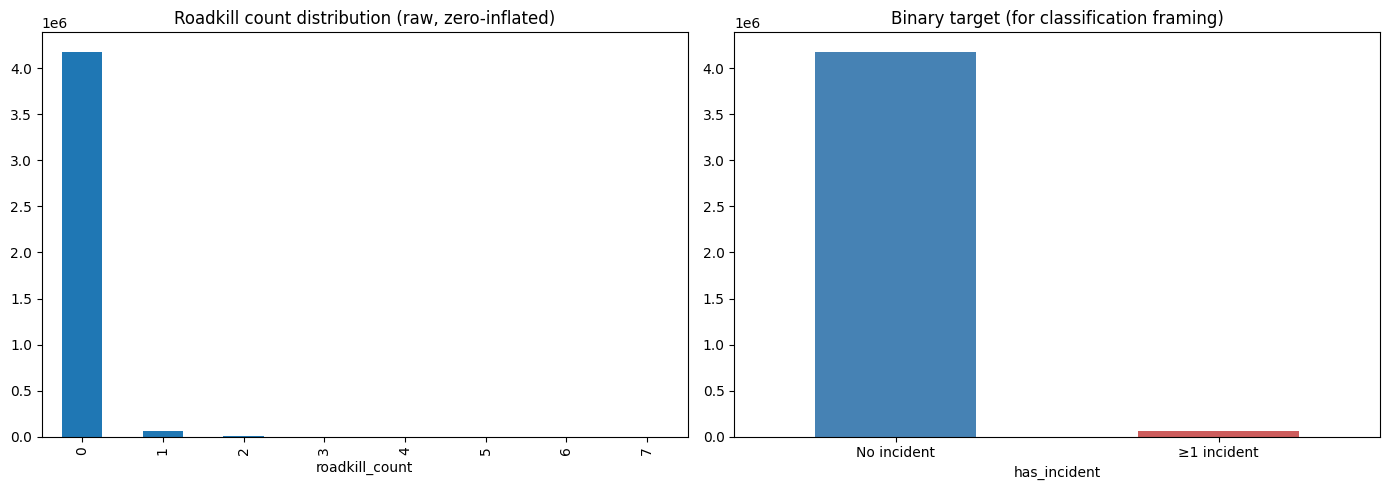


2. SEASONALITY — incident rate by month
month
1     0.009963
2     0.007446
3     0.007900
4     0.007892
5     0.012297
6     0.017084
7     0.018259
8     0.018293
9     0.019333
10    0.025199
11    0.026694
12    0.011933
Name: has_incident, dtype: float64


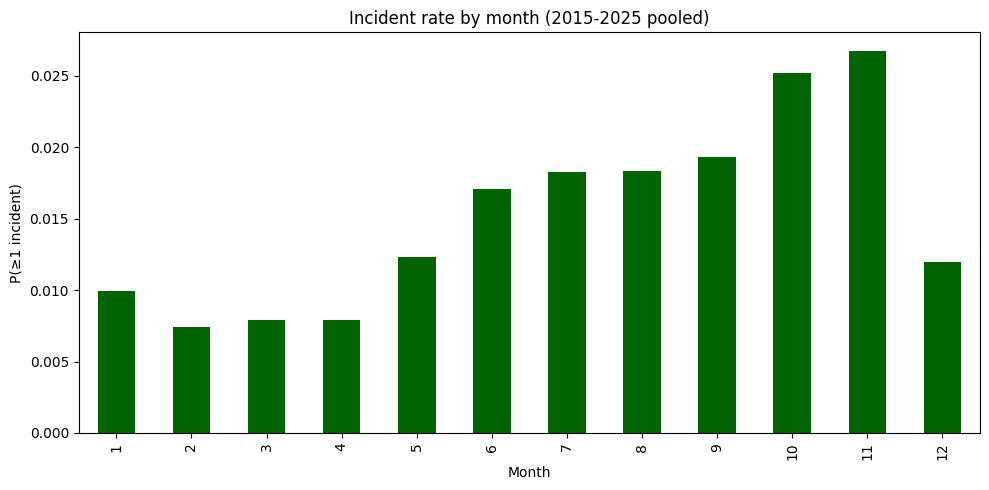


Incident rate by year:
year
2015    0.016419
2016    0.016901
2017    0.016549
2018    0.018354
2019    0.015870
2020    0.015419
2021    0.013873
2022    0.012731
2023    0.013391
2024    0.014034
2025    0.013562
Name: has_incident, dtype: float64

3. MISSING VALUES
migration_GRIDCODE         0.962080
migration_overlap_count    0.962080
donor_distance_m           0.881764
donor_elev_diff_m          0.881764
ocamp_overlap_count        0.598639
ocamp_Name                 0.598639
ocamp_Descr                0.598639
rural_urban                0.495105
functional_class           0.494638
max_aadt                   0.493799
station_count              0.493799
mean_aadt                  0.493799
GEOID                      0.000062
pop_density_per_km2        0.000062
area_km2                   0.000062
population                 0.000062
dtype: float64


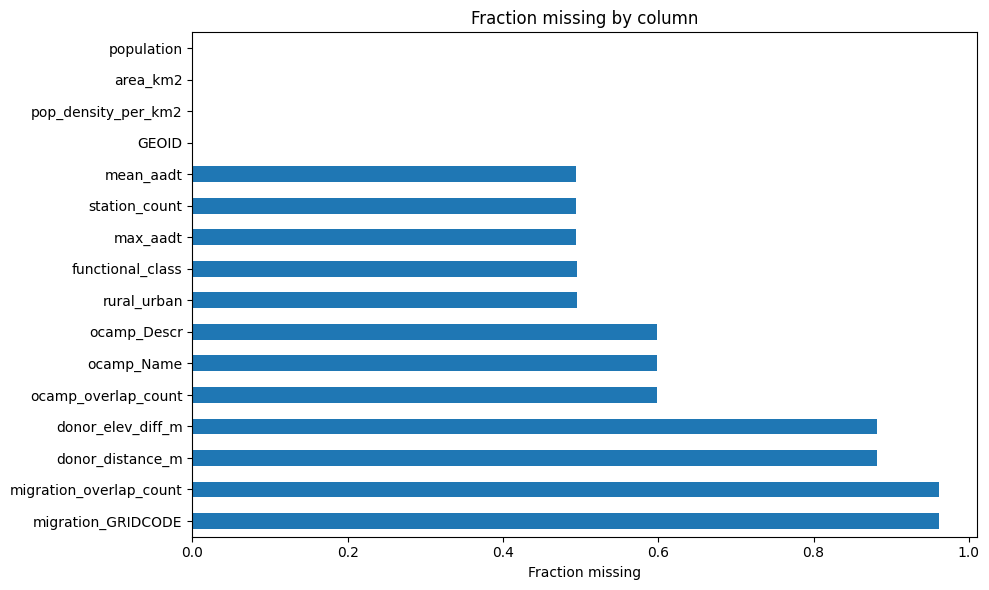


4. NUMERIC PREDICTOR DISTRIBUTIONS
                           count         mean           std        min  \
ppt_mean               4246836.0    77.095952     95.745233   0.000000   
tmean_mean             4246836.0    10.782990      6.851544 -12.422501   
elevation_mean_m       4246836.0   480.352158    491.196217   0.373347   
slope_mean_deg         4246836.0     3.359615      4.910035   0.000000   
pop_density_per_km2    4246572.0   286.907011    715.907672   0.000000   
mean_aadt              2149752.0  8665.345647  11807.504793   1.000000   
habitat_overlap_count  4246836.0     1.355329      0.553312   1.000000   

                               25%          50%           75%            max  
ppt_mean                 14.614799    40.492001    105.545998    1339.801025  
tmean_mean                5.643400    10.279099     16.406000      30.158998  
elevation_mean_m         63.377802   219.932427    893.810493    1951.409526  
slope_mean_deg            0.000000     1.480735      4.

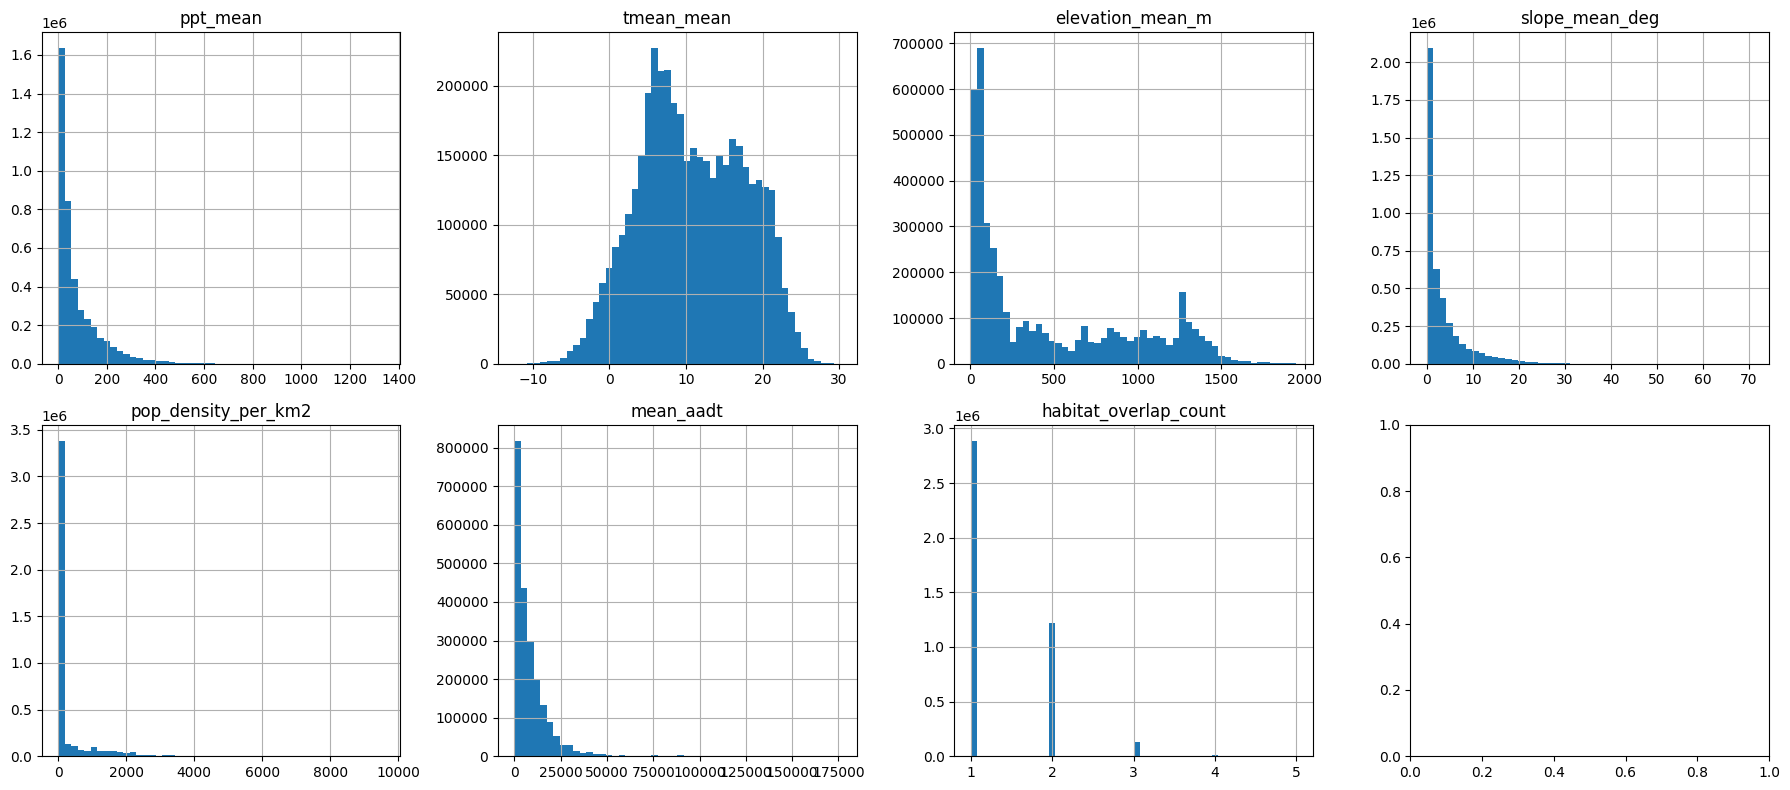


5. PREDICTOR MEANS: incident vs no-incident
                       no_incident_mean  incident_mean        diff
mean_aadt                   8668.584616    8377.222116 -291.362500
pop_density_per_km2          289.583511     113.405502 -176.178008
elevation_mean_m             479.304228     548.287481   68.983253
ppt_mean                      77.345100      60.944116  -16.400984
tmean_mean                    10.770103      11.618420    0.848317
slope_mean_deg                 3.355715       3.612474    0.256759
habitat_overlap_count          1.353884       1.448988    0.095104


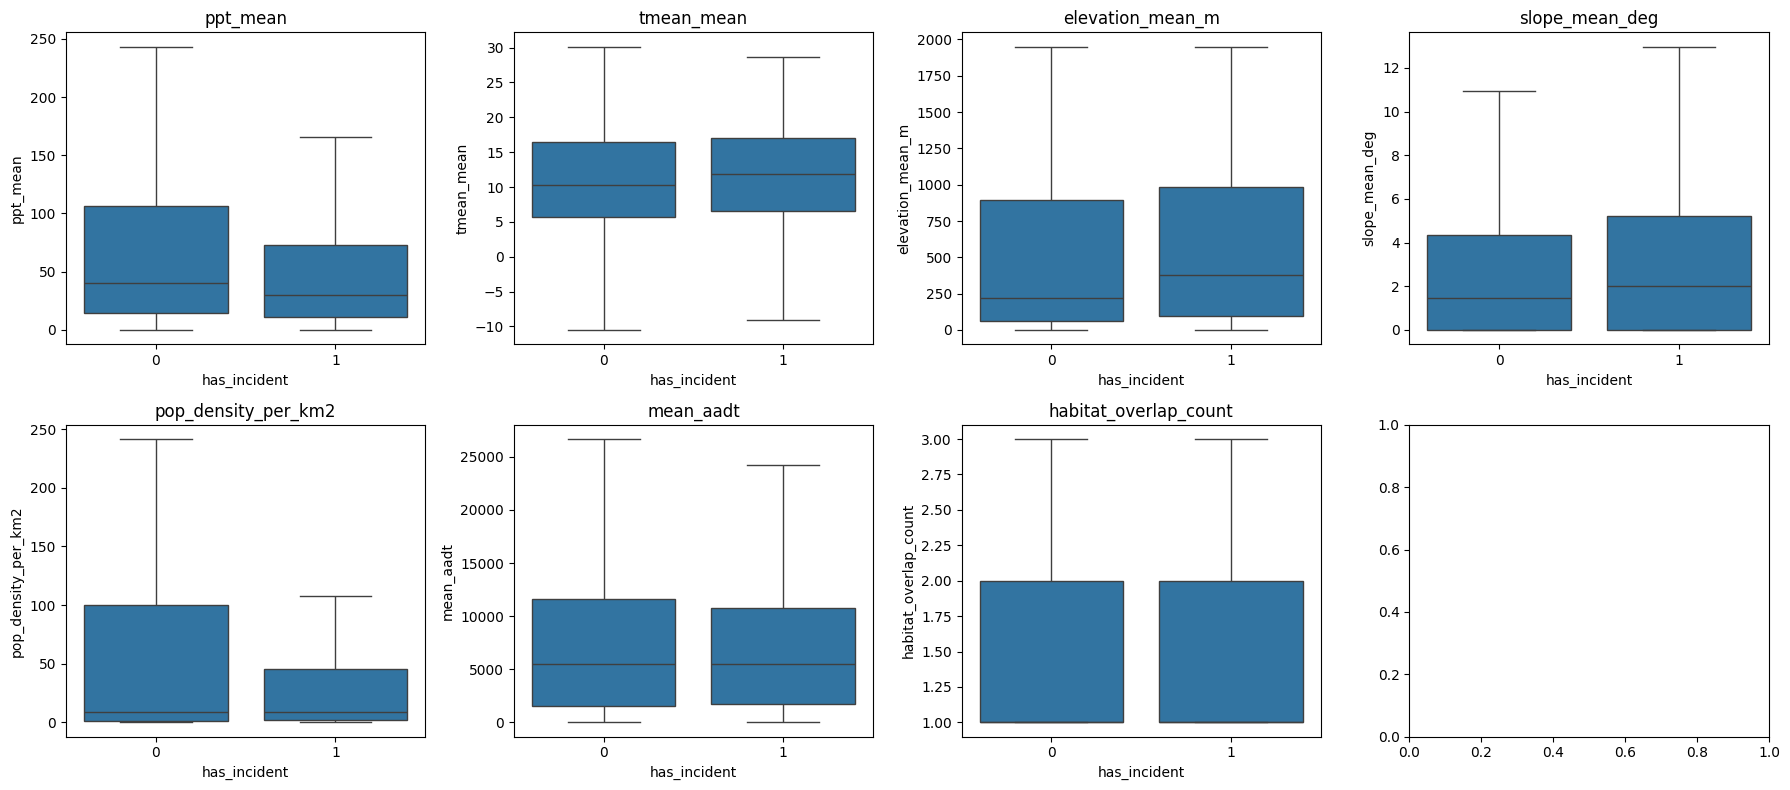


6. CORRELATION MATRIX (numeric predictors)
roadkill_count           1.000000
habitat_overlap_count    0.020784
elevation_mean_m         0.017005
tmean_mean               0.013402
slope_mean_deg           0.006112
mean_aadt               -0.002296
ppt_mean                -0.020346
pop_density_per_km2     -0.028675
Name: roadkill_count, dtype: float64


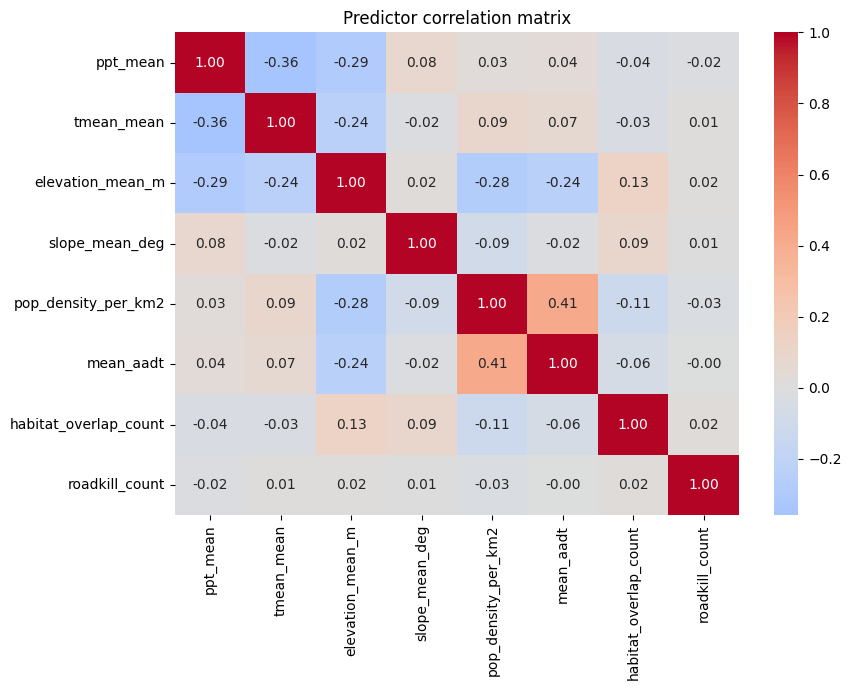


7. INCIDENT RATE BY CATEGORICAL FEATURE

--- habitat_veg_name ---
                                                        mean  count
habitat_veg_name                                                   
Agricultural cropland and pastureland/Big sageb...  0.064216  19668
Annual grasslands/Western juniper-bunchgrass        0.063973   2376
Agricultural cropland and pastureland/Cottonwoo...  0.052001  13596
Big sagebrush-bitterbrush-bluebunch wheatgrass      0.049953   8448
Western juniper-mountain big sagebrush-Idaho fe...  0.046839  13728
Western juniper-big sagebrush-bitterbrush           0.045097  16764
Siskiyou-Sierra mixed conifer woodland on ultra...  0.040152   1320
Siskiyou mixed evergreen forest                     0.035312  56496
Big sagebrush-basin wildrye/Low sagebrush Idaho...  0.033144   1056
Ponderosa pine forests and woodlands on pumace      0.032942  32208
Big sagebrush-basin wildrye                         0.032828   1584
Oak-Pacific madrone forest and woodland          

In [23]:
"""
Cell 21 - EDA

"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("/content/drive/MyDrive/wvc_capstone/master_panel.parquet")
plt.rcParams["figure.figsize"] = (10, 5)

# ============================================================
# 1. TARGET VARIABLE — distribution, imbalance, zero-inflation
# ============================================================
print("=" * 70)
print("1. TARGET VARIABLE: roadkill_count")
print("=" * 70)
print(df["roadkill_count"].describe())
print(f"\nPositive rate: {(df['roadkill_count'] > 0).mean():.4f}")
print(f"\nValue counts:\n{df['roadkill_count'].value_counts().sort_index()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["roadkill_count"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Roadkill count distribution (raw, zero-inflated)")
axes[0].set_xlabel("roadkill_count")

df["has_incident"] = (df["roadkill_count"] > 0).astype(int)
df["has_incident"].value_counts().plot(kind="bar", ax=axes[1], color=["steelblue", "indianred"])
axes[1].set_title("Binary target (for classification framing)")
axes[1].set_xticklabels(["No incident", "≥1 incident"], rotation=0)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/wvc_capstone/eda_target_dist.png", dpi=120)
plt.show()

# ============================================================
# 2. SEASONALITY — does risk vary by month? (core hypothesis)
# ============================================================
print("\n" + "=" * 70)
print("2. SEASONALITY — incident rate by month")
print("=" * 70)
monthly = df.groupby("month")["has_incident"].mean()
print(monthly)

plt.figure()
monthly.plot(kind="bar", color="darkgreen")
plt.title("Incident rate by month (2015-2025 pooled)")
plt.ylabel("P(≥1 incident)")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/wvc_capstone/eda_seasonality.png", dpi=120)
plt.show()

# year trend too — is there drift over time worth knowing about?
print("\nIncident rate by year:")
print(df.groupby("year")["has_incident"].mean())

# ============================================================
# 3. MISSINGNESS MAP — visual overview of what's incomplete
# ============================================================
print("\n" + "=" * 70)
print("3. MISSING VALUES")
print("=" * 70)
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

plt.figure(figsize=(10, 6))
missing.plot(kind="barh")
plt.title("Fraction missing by column")
plt.xlabel("Fraction missing")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/wvc_capstone/eda_missingness.png", dpi=120)
plt.show()

# ============================================================
# 4. NUMERIC PREDICTOR DISTRIBUTIONS
# ============================================================
print("\n" + "=" * 70)
print("4. NUMERIC PREDICTOR DISTRIBUTIONS")
print("=" * 70)
numeric_cols = [
    "ppt_mean", "tmean_mean", "elevation_mean_m", "slope_mean_deg",
    "pop_density_per_km2", "mean_aadt", "habitat_overlap_count",
]
numeric_cols = [c for c in numeric_cols if c in df.columns]
print(df[numeric_cols].describe().T)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].dropna().hist(bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/wvc_capstone/eda_numeric_dists.png", dpi=120)
plt.show()

# ============================================================
# 5. PREDICTOR vs TARGET — does each feature actually separate
#    incident / non-incident segment-months?
# ============================================================
print("\n" + "=" * 70)
print("5. PREDICTOR MEANS: incident vs no-incident")
print("=" * 70)
comparison = df.groupby("has_incident")[numeric_cols].mean().T
comparison.columns = ["no_incident_mean", "incident_mean"]
comparison["diff"] = comparison["incident_mean"] - comparison["no_incident_mean"]
print(comparison.sort_values("diff", key=abs, ascending=False))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=df, x="has_incident", y=col, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/wvc_capstone/eda_feature_vs_target.png", dpi=120)
plt.show()

# ============================================================
# 6. CORRELATION MATRIX — multicollinearity check
# ============================================================
print("\n" + "=" * 70)
print("6. CORRELATION MATRIX (numeric predictors)")
print("=" * 70)
corr_cols = numeric_cols + ["roadkill_count"]
corr = df[corr_cols].corr()
print(corr["roadkill_count"].sort_values(ascending=False))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Predictor correlation matrix")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/wvc_capstone/eda_correlation.png", dpi=120)
plt.show()

# ============================================================
# 7. CATEGORICAL FEATURES — habitat type, functional class, etc.
# ============================================================
print("\n" + "=" * 70)
print("7. INCIDENT RATE BY CATEGORICAL FEATURE")
print("=" * 70)
for col in ["habitat_veg_name", "functional_class", "rural_urban", "migration_in_ranked_corridor"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        rate = df.groupby(col)["has_incident"].agg(["mean", "count"]).sort_values("mean", ascending=False)
        print(rate.head(15))

print("\n" + "=" * 70)
print("Saved plots to /content/drive/MyDrive/wvc_capstone/eda_*.png")
print("=" * 70)

In [25]:
"""
Cell 22 - Table View.

"""
import pandas as pd
from google.colab import data_table
data_table.enable_dataframe_formatter()

df = pd.read_parquet("/content/drive/MyDrive/wvc_capstone/master_panel.parquet")
df.head(500)

,segment_id,grid_id,year,month,ppt_mean,tmean_mean,weather_imputed,donor_distance_m,donor_elev_diff_m,roadkill_count,...,ocamp_Descr,migration_overlap_count,migration_intersects,migration_GRIDCODE,migration_in_ranked_corridor,mean_aadt,max_aadt,station_count,functional_class,rural_urban
0,seg_0,-2672_3554,2015,1,270.688995,8.031000,False,NaN,NaN,0,...,None,NaN,False,NaN,False,NaN,NaN,NaN,None,None
1,seg_0,-2672_3554,2015,2,261.177002,9.784000,False,NaN,NaN,0,...,None,NaN,False,NaN,False,NaN,NaN,NaN,None,None
2,seg_0,-2672_3554,2015,3,240.335999,9.631001,False,NaN,NaN,0,...,None,NaN,False,NaN,False,NaN,NaN,NaN,None,None
3,seg_0,-2672_3554,2015,4,128.770996,9.060000,False,NaN,NaN,0,...,None,NaN,False,NaN,False,NaN,NaN,NaN,None,None
4,seg_0,-2672_3554,2015,5,55.293999,12.070001,False,NaN,NaN,0,...,None,NaN,False,NaN,False,NaN,NaN,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,seg_3,-2626_3468,2023,4,160.045898,9.033999,False,NaN,NaN,0,...,None,NaN,False,NaN,False,NaN,NaN,NaN,None,None
496,seg_3,-2626_3468,2023,5,15.981600,15.915999,False,NaN,NaN,0,...,None,NaN,False,NaN,False,NaN,NaN,NaN,None,None
497,seg_3,-2626_3468,2023,6,7.570600,16.778599,False,NaN,NaN,0,...,None,NaN,False,NaN,False,NaN,NaN,NaN,None,None
498,seg_3,-2626_3468,2023,7,0.406800,20.933500,False,NaN,NaN,0,...,None,NaN,False,NaN,False,NaN,NaN,NaN,None,None


In [31]:
import os
from google.colab import userdata
os.environ["GITHUB_TOKEN"] = userdata.get("GITHUB_TOKEN")
print("Token loaded:", bool(os.environ["GITHUB_TOKEN"]))

Token loaded: True


In [32]:
%%bash
set -e

REPO_URL="https://${GITHUB_TOKEN}@github.com/vkrmgl/Wildlife-Capstone.git"
CLONE_DIR="/content/wildlife-capstone-push"
DRIVE_DIR="/content/drive/MyDrive/wvc_capstone"
BRANCH="data-compilation"

rm -rf "$CLONE_DIR"
git clone "$REPO_URL" "$CLONE_DIR"
cd "$CLONE_DIR"
git config user.email "$(git config --global user.email || echo 'you@example.com')"
git config user.name "$(git config --global user.name || echo 'Ewura')"
git checkout -b "$BRANCH" origin/main

mkdir -p notebooks data/processed

cp "$DRIVE_DIR/210_data.ipynb" notebooks/wvc_capstone_pipeline.ipynb
cp "$DRIVE_DIR/master_panel.parquet" data/processed/master_panel.parquet

PARQUET_SIZE=$(stat -c%s data/processed/master_panel.parquet)
echo "master_panel.parquet size: $((PARQUET_SIZE / 1024 / 1024)) MB"

if [ "$PARQUET_SIZE" -gt 90000000 ]; then
    echo "Over ~90MB - setting up Git LFS for this file."
    git lfs install
    git lfs track "data/processed/master_panel.parquet"
    git add .gitattributes
fi

git add -f data/processed/master_panel.parquet
git add notebooks/wvc_capstone_pipeline.ipynb

git commit -m "Add weather/terrain/census/habitat pipeline notebook and master panel dataset"
git push -u origin "$BRANCH"

echo ""
echo "Pushed to branch: $BRANCH"
echo "Open a PR at: https://github.com/vkrmgl/Wildlife-Capstone/compare/main...$BRANCH"

branch 'data-compilation' set up to track 'origin/main'.
master_panel.parquet size: 29 MB
[data-compilation 3d42097] Add weather/terrain/census/habitat pipeline notebook and master panel dataset
 2 files changed, 1 insertion(+)
 create mode 100644 data/processed/master_panel.parquet
 create mode 100644 notebooks/wvc_capstone_pipeline.ipynb


Cloning into '/content/wildlife-capstone-push'...
Switched to a new branch 'data-compilation'
remote: error: GH013: Repository rule violations found for refs/heads/data-compilation.        
remote: 
remote: - GITHUB PUSH PROTECTION        
remote:   —————————————————————————————————————————        
remote:     Resolve the following violations before pushing again        
remote: 
remote:     - Push cannot contain secrets        
remote: 
remote:             
remote:      (?) Learn how to resolve a blocked push        
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push        
remote:             
remote:             
remote:       —— GitHub Personal Access Token ——————————————————————        
remote:        locations:        
remote:          - commit: 3d42097e73ceadb06d6d8946e7b3a31fb4664148        
remote:            path: notebooks/wvc_capstone

CalledProcessError: Command 'b'set -e\n\nREPO_URL="https://${GITHUB_TOKEN}@github.com/vkrmgl/Wildlife-Capstone.git"\nCLONE_DIR="/content/wildlife-capstone-push"\nDRIVE_DIR="/content/drive/MyDrive/wvc_capstone"\nBRANCH="data-compilation"\n\nrm -rf "$CLONE_DIR"\ngit clone "$REPO_URL" "$CLONE_DIR"\ncd "$CLONE_DIR"\ngit config user.email "$(git config --global user.email || echo \'you@example.com\')"\ngit config user.name "$(git config --global user.name || echo \'Ewura\')"\ngit checkout -b "$BRANCH" origin/main\n\nmkdir -p notebooks data/processed\n\ncp "$DRIVE_DIR/210_data.ipynb" notebooks/wvc_capstone_pipeline.ipynb\ncp "$DRIVE_DIR/master_panel.parquet" data/processed/master_panel.parquet\n\nPARQUET_SIZE=$(stat -c%s data/processed/master_panel.parquet)\necho "master_panel.parquet size: $((PARQUET_SIZE / 1024 / 1024)) MB"\n\nif [ "$PARQUET_SIZE" -gt 90000000 ]; then\n    echo "Over ~90MB - setting up Git LFS for this file."\n    git lfs install\n    git lfs track "data/processed/master_p